# Portfolio Drift Monitor — Project Pipeline

**The spine of the project.** Started in Stage 04 and extended by every stage
that follows. Each stage appends a section; the whole notebook is re-run top to
bottom before every commit, so "the earlier stages still work" is verified
rather than assumed.

| Stage | Section below |
|---|---|
| 04 Data Acquisition | ingest VTI / VXUS / BND, validate, save to `data/raw/` |
| 05 Data Storage | *(added next stage)* |

**Run order matters.** Cells below assume the ones above have run in sequence.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')                               # project/notebooks -> project
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))                # so `from src....` imports work
print('working from:', ROOT.name)

working from: project


In [2]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

from src.utils import TARGET_WEIGHTS, to_weights, drift_pp, flag_drift

load_dotenv()
RAW = Path(os.getenv('DATA_DIR_RAW', 'data/raw'))
PROC = Path(os.getenv('DATA_DIR_PROCESSED', 'data/processed'))
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('RAW  ->', RAW)
print('PROC ->', PROC)
print('targets:', TARGET_WEIGHTS)

RAW  -> data/raw
PROC -> data/processed
targets: {'VTI': 0.6, 'VXUS': 0.3, 'BND': 0.1}


---

## Stage 04 — Data Acquisition & Ingestion

Daily closes for the three funds in the model portfolio, pulled from yfinance
and saved to `data/raw/` under a timestamped filename. Nothing here edits an
existing file: a re-run adds a new one, so any earlier state stays recoverable.

**Why raw `close` and not adjusted close.** Adjusted close is a paid field at
Alpha Vantage, so the ingestion path that survives vendor changes is the one
that never assumed the column existed. The cost is that dividends and splits are
not reflected — fine for short-window weight drift, wrong for long-horizon
returns, and stated here so it cannot be forgotten downstream.

In [3]:
TICKERS = list(TARGET_WEIGHTS.keys())        # VTI, VXUS, BND
PERIOD = '1y'


def ingest_prices(tickers, period=PERIOD):
    # Returns a long frame: one row per (date, ticker).
    import yfinance as yf
    raw = yf.download(tickers, period=period, interval='1d',
                      auto_adjust=False, progress=False)

    # Code against the SHAPE that comes back, not the shape we remember:
    # yfinance returns a MultiIndex for multi-ticker requests and a flat one
    # for a single ticker, and the level order has changed between versions.
    close = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw[['Close']]
    if not isinstance(raw.columns, pd.MultiIndex):
        close.columns = tickers

    out = (close.reset_index()
                .melt(id_vars='Date', var_name='ticker', value_name='close')
                .rename(columns={'Date': 'date'})
                .dropna(subset=['close'])
                .sort_values(['date', 'ticker'])
                .reset_index(drop=True))
    out['date'] = pd.to_datetime(out['date'])
    out['close'] = pd.to_numeric(out['close'])
    return out


prices_long = ingest_prices(TICKERS)
print(prices_long.shape)
prices_long.head()

(753, 3)


,date,ticker,close
0,2025-08-29,BND,73.800003
1,2025-08-29,VTI,318.200012
2,2025-08-29,VXUS,71.370003
3,2025-09-02,BND,73.400002
4,2025-09-02,VTI,315.989990


In [4]:
def validate_prices(df, tickers):
    # Schema, types, completeness, sanity - the four checks from Stage 04.
    checks = {
        'required_cols': all(col in df.columns for col in ['date', 'ticker', 'close']),
        'date_is_datetime': pd.api.types.is_datetime64_any_dtype(df['date']),
        'close_is_numeric': pd.api.types.is_numeric_dtype(df['close']),
        'all_tickers_present': set(tickers) == set(df['ticker'].unique()),
        'na_total': int(df.isna().sum().sum()),
        'duplicate_rows': int(df.duplicated(subset=['date', 'ticker']).sum()),
        'all_prices_positive': bool((df['close'] > 0).all()),
        'rows_per_ticker': df.groupby('ticker').size().to_dict(),
    }
    return checks


checks = validate_prices(prices_long, TICKERS)
for key, value in checks.items():
    print(f"{key:<22} {value}")

required_cols          True
date_is_datetime       True
close_is_numeric       True
all_tickers_present    True
na_total               0
duplicate_rows         0
all_prices_positive    True
rows_per_ticker        {'BND': 251, 'VTI': 251, 'VXUS': 251}


In [5]:
# Fail loudly rather than saving something malformed.
assert checks['required_cols'],        'missing required columns'
assert checks['all_tickers_present'],  'a ticker is missing from the pull'
assert checks['all_prices_positive'],  'non-positive price'
assert checks['duplicate_rows'] == 0,  'duplicate (date, ticker) rows'
assert checks['na_total'] == 0,        'unexpected missing values'
print('validation passed')

validation passed


In [6]:
def ts():
    return dt.datetime.now().strftime('%Y%m%d-%H%M')


raw_path = RAW / f"api_yfinance_{'-'.join(TICKERS)}_{ts()}.csv"
prices_long.to_csv(raw_path, index=False)
print('saved', raw_path, f'({len(prices_long)} rows)')

saved data/raw/api_yfinance_VTI-VXUS-BND_20260830-1023.csv (753 rows)


---

## Stage 06 - Cleaning, between raw and processed

Raw is what the vendor said. Processed is what I am willing to compute on. Cleaning is the
boundary between the two, so it belongs exactly here: after the raw file is written to disk,
before a single weight is calculated.

`src/cleaning.py` deliberately does **not** reuse the median rule from
`homework/homework06/src/cleaning.py`. That module cleans a cross-section of seven unrelated
people, where the column median is a fair stand-in for a blank. This is a time series, where
it is not. The median of a year of VTI closes is not a plausible price for any particular
Tuesday, and substituting it would invent a move the market never made. Here a missing close
is carried forward from the last observation, capped at three days, and anything longer stays
visible and gets dropped.

**The order of operations, and why it is not interchangeable:**

1. **Coerce types.** The raw file is CSV, and Stage 05 established that CSV is text and
   forgets dtypes. Everything below depends on `date` being a real datetime and `close` a
   real float.
2. **Sort by (date, ticker).** Forward fill walks the frame in row order. On an unsorted
   frame it propagates prices *backwards* through time.
3. **Drop duplicate (date, ticker).** Before filling, so a duplicate cannot become the source
   of a fill for its own twin. `keep='last'`, on the assumption that a resent day is a
   correction - which is an assumption about the vendor, not a fact.
4. **Non-positive closes to missing.** A close of zero is not a cheap fund, it is a broken
   record.
5. **Forward fill, limit three days.** A long weekend plus a holiday. Filling further draws a
   flat line through the gap, and a flat line is a positive claim of zero volatility, not an
   absence of data.
6. **Drop incomplete days.** Last, because step 5 may have repaired a day that was incomplete
   when it arrived.

In [7]:
from src import cleaning

# Clean what was actually persisted, not what happens to still be in memory. Reloading is the
# only way to show the file on disk is usable - and it is what tomorrow's run will do.
raw_reloaded = pd.read_csv(raw_path)

print('reloaded', raw_path.name, raw_reloaded.shape)
print()
print(cleaning.missingness_report(raw_reloaded).to_string())

reloaded api_yfinance_VTI-VXUS-BND_20260830-1023.csv (753, 3)

          dtype  missing  missing_pct
date     object        0          0.0
ticker   object        0          0.0
close   float64        0          0.0


In [8]:
prices_clean, clean_log = cleaning.clean_prices(raw_reloaded, TICKERS)

for key, value in clean_log.items():
    print(f'{key:<28} {value}')

rows_in                      753
unparseable_values           {'date': 0, 'close': 0}
duplicate_rows_removed       0
non_positive_prices          0
missing_closes_before_fill   0
closes_forward_filled        0
incomplete_days_dropped      0
dropped_dates                []
rows_out                     753
rows_removed                 0


Every counter is zero: today's pull needed nothing done to it. That is the expected result for
one vendor on three of the most liquid funds listed, and it is also the least informative test
available. **A cleaning step that has never changed a number is indistinguishable from one
that cannot.** So the next cell breaks a copy on purpose and checks that the same code repairs
it.

In [9]:
# Five faults, one of each kind the module claims to handle.
dates = sorted(raw_reloaded['date'].unique())
d_nan, d_zero, gap = dates[20], dates[35], dates[50:54]

damaged = raw_reloaded.copy()
damaged['date'] = damaged['date'].astype(str)                                        # 1. dtypes lost
damaged.loc[(damaged['date'] == d_nan) & (damaged['ticker'] == 'VXUS'), 'close'] = np.nan   # 2. missed close
damaged.loc[(damaged['date'] == d_zero) & (damaged['ticker'] == 'VTI'), 'close'] = 0.0      # 3. broken record
damaged = pd.concat([damaged,
                     damaged[(damaged['date'] == dates[5]) &
                             (damaged['ticker'] == 'BND')]], ignore_index=True)      # 4. vendor resend
damaged = damaged[~((damaged['date'].isin(gap)) & (damaged['ticker'] == 'BND'))]     # 5. a fund absent 4 days
damaged = damaged.sample(frac=1, random_state=6).reset_index(drop=True)              #    and out of order

damaged_clean, damaged_log = cleaning.clean_prices(damaged, TICKERS)

for key, value in damaged_log.items():
    print(f'{key:<28} {value}')

rows_in                      750
unparseable_values           {'date': 0, 'close': 0}
duplicate_rows_removed       1
non_positive_prices          1
missing_closes_before_fill   2
closes_forward_filled        2
incomplete_days_dropped      4
dropped_dates                ['2025-11-10', '2025-11-11', '2025-11-12', '2025-11-13']
rows_out                     741
rows_removed                 9


In [10]:
# Does the repaired frame match the series already known to be true?
truth = prices_clean[~prices_clean['date'].isin(pd.to_datetime(gap))]
merged = damaged_clean.merge(truth, on=['date', 'ticker'], suffixes=('_repaired', '_true'))

print('rows compared  :', len(merged))
print('rows identical :', int(np.isclose(merged['close_repaired'], merged['close_true']).sum()))

differs = merged[~np.isclose(merged['close_repaired'], merged['close_true'])].copy()
differs['error_bps'] = (differs['close_repaired'] / differs['close_true'] - 1) * 1e4
print()
print('the forward-filled cells, and what the fill cost:')
print(differs.round(2).to_string(index=False))

rows compared  : 741
rows identical : 739

the forward-filled cells, and what the fill cost:
      date ticker  close_repaired  close_true  error_bps
2025-09-29   VXUS           72.75       73.14     -53.32
2025-10-20    VTI          327.30      330.95    -110.29


The repair is exact everywhere except the two cells that were forward-filled, and those are
wrong by roughly half a percent - the size of one day's move in a broad equity fund, which is
precisely what a one-day-stale price is. The error is small, it is bounded by the fill limit,
and it is in the log rather than hidden. That is the trade the fill makes, stated in basis
points instead of adjectives.

The four days where BND was absent entirely are gone rather than repaired, and the next cell
is the argument for why.

In [11]:
# What would keeping an incomplete day have done to the report Dana opens?
day = pd.Timestamp(gap[0])
wide_chk = prices_clean.pivot(index='date', columns='ticker', values='close')[TICKERS]
tgt = [TARGET_WEIGHTS[t] for t in TICKERS]

shares_chk = (1_000_000 * np.array(tgt)) / wide_chk.iloc[0].to_numpy()
vals = wide_chk.loc[day].to_numpy() * shares_chk

honest = vals / vals.sum()                                    # all three funds present
partial = np.where(np.array(TICKERS) == 'BND', 0.0, vals)     # BND silently absent
partial = partial / partial.sum()

counterfactual = pd.DataFrame({
    'fund': TICKERS,
    'weight_if_BND_missing': partial,
    'true_weight': honest,
    'drift_pp_if_missing': drift_pp(partial, tgt),
    'true_drift_pp': drift_pp(honest, tgt),
})
counterfactual['flag_if_missing'] = flag_drift(counterfactual['drift_pp_if_missing'])
counterfactual['true_flag'] = flag_drift(counterfactual['true_drift_pp'])
counterfactual.round(3)

,fund,weight_if_BND_missing,true_weight,drift_pp_if_missing,true_drift_pp,flag_if_missing,true_flag
0,VTI,0.667,0.603,6.664,0.259,red,green
1,VXUS,0.333,0.301,3.336,0.133,amber,green
2,BND,0.000,0.096,-10.000,-0.392,red,green


Read `flag_if_missing` against `true_flag`. One absent fund on one day puts VTI at about 67%
against a 60% target - a drift near 6.7pp and a **red** flag - on a day when the portfolio was
in fact within a fraction of a point of target and unambiguously green. The arithmetic is not
a coincidence and does not depend on the window: drop a 10% sleeve and the remaining weights
are divided by 0.9, which lifts a 60% target to 66.7% on its own.

That connects directly to the finding recorded at the end of Stage 05. On a year of real
closes the 5pp red threshold **never fires**. This cell shows that the only way this monitor
*would* have produced a red flag over that year is a hole in the data. An alert that fires
only on bad data is worse than no alert at all: it teaches Dana that red means "ignore this,
the file is broken", which is exactly the reflex a risk control cannot afford.

So `drop_incomplete_days` drops rather than fills, and it is the one rule in the module with
no configurable alternative. Weights computed on a partial day are not missing, they are
**wrong** - and wrong in a way that looks entirely reasonable on the report.

**What this cleaning costs, honestly.** On today's data, nothing: every counter is zero and
`prices_clean` is row-for-row the raw pull. On damaged data it costs the four dropped days
(about 1.6% of a one-year window) and two forward-filled closes carrying roughly 50 to 110 bps
of error each. The dropped days are the expensive half and the defensible one. The forward
fills are the cheap half and the one to watch: they are estimates wearing the same dtype as
observations, and nothing downstream can tell them apart once the log scrolls past. A
`close_was_filled` indicator column is the obvious Stage 09 feature, and it is not here yet.

In [12]:
from src.utils import write_df, read_df

# The cleaned price table is an artifact in its own right: it is what every later stage starts
# from, and saving it means Stage 07 does not have to re-download to reproduce Stage 06.
clean_path = write_df(prices_clean, PROC / f'prices_clean_{ts()}.parquet')
print('saved', clean_path, f'({len(prices_clean)} rows)')

back = read_df(clean_path)
assert back.shape == prices_clean.shape,                     'round trip changed the shape'
assert pd.api.types.is_datetime64_any_dtype(back['date']),   'date came back as text'
assert np.allclose(back['close'], prices_clean['close']),    'closes changed'
print('round trip verified')

saved data/processed/prices_clean_20260830-1023.parquet (753 rows)
round trip verified


### From raw prices to the report

The Stage 03 helpers now run on real data instead of simulated data, unchanged.
That was the test: if `to_weights`, `drift_pp` and `flag_drift` needed editing
to accept real input, they were written at the wrong level of abstraction.

Share counts are set so the portfolio sat exactly on target on the **first day
of the window**. Every deviation since is price movement alone — no deposits,
no withdrawals, no rebalancing.

In [13]:
# Built from prices_clean, not prices_long: nothing downstream touches raw.
wide = prices_clean.pivot(index='date', columns='ticker', values='close')[TICKERS]

PORTFOLIO_VALUE = 1_000_000
targets = np.array([TARGET_WEIGHTS[t] for t in TICKERS])
shares = (PORTFOLIO_VALUE * targets) / wide.iloc[0].to_numpy()

values = wide.to_numpy() * shares
weights = values / values.sum(axis=1, keepdims=True)

# Day 0 is on target by construction - assert it, do not assume it.
assert np.allclose(weights[0], targets), 'day 0 should sit exactly on target'
print(f"window: {wide.index.min().date()} to {wide.index.max().date()}  ({len(wide)} trading days)")

window: 2025-08-29 to 2026-08-28  (251 trading days)


In [14]:
latest = weights[-1]

report = pd.DataFrame({
    'fund': TICKERS,
    'target_weight': targets,
    'current_weight': latest,
    'drift_pp': drift_pp(latest, targets),
})
report['flag'] = flag_drift(report['drift_pp'])
report.round(4)

,fund,target_weight,current_weight,drift_pp,flag
0,VTI,0.6,0.6056,0.5596,green
1,VXUS,0.3,0.3115,1.1453,green
2,BND,0.1,0.0830,-1.7049,green


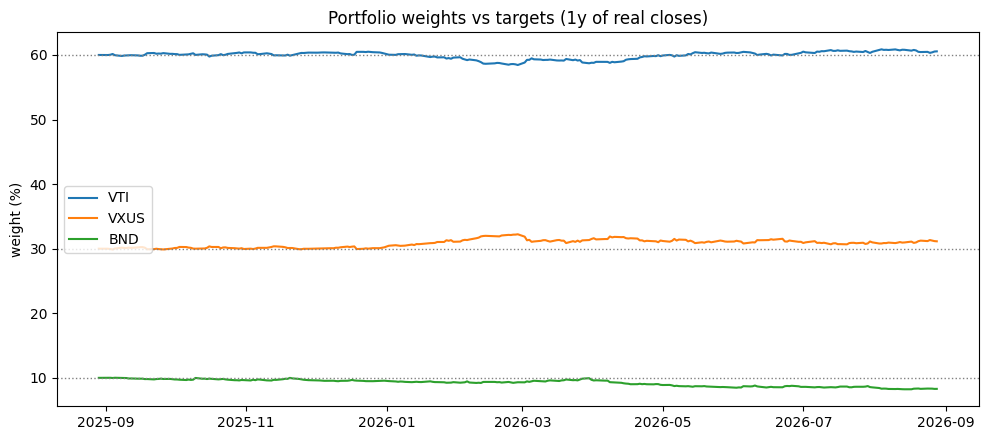

In [15]:
weights_df = pd.DataFrame(weights, index=wide.index, columns=TICKERS)

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, ticker in enumerate(TICKERS):
    ax.plot(weights_df.index, weights_df[ticker] * 100, label=ticker)
    ax.axhline(targets[i] * 100, linestyle=':', linewidth=1, color='grey')

ax.set_title(f'Portfolio weights vs targets ({PERIOD} of real closes)')
ax.set_ylabel('weight (%)')
ax.legend(loc='center left')
fig.tight_layout()
plt.show()

### Sources, parameters and validations

| | |
|---|---|
| Source | yfinance daily closes for VTI, VXUS, BND |
| Parameters | `period='1y'`, `interval='1d'`, `auto_adjust=False` |
| Secrets | `.env` (`DATA_DIR_RAW`, `DATA_DIR_PROCESSED`, `ALPHAVANTAGE_API_KEY`); never committed |
| Output | `data/raw/api_yfinance_VTI-VXUS-BND_<YYYYMMDD-HHMM>.csv` |
| Validation | required columns · dtypes · all tickers present · no NAs · no duplicate (date, ticker) · all prices positive · row counts per ticker |

**Assumptions and risks**

- **Raw close, not adjusted** — dividends and splits are not reflected. Fine for
  weight drift over a one-year window; wrong for computing total return.
- **Prices only.** Weights ignore accrued dividends and any cash sleeve.
- **The model portfolio, not a client account.** No deposits or withdrawals, so
  drift here is a pure price effect. A real account will differ.
- **Vendor dependence.** yfinance is an unofficial wrapper around a public
  endpoint and can break without notice. The shape check on the returned
  columns is deliberate, not defensive noise.
- **Re-running produces a new file** rather than overwriting, which is what
  makes an earlier pull reproducible — at the cost of a growing `data/raw/`.

**Next stage (05):** save a processed table to `data/processed/` in Parquet,
add `write_df` / `read_df` utilities, and append a Data Storage section to the
project README.

---

## Stage 05 — Data Storage

The daily report is a **derived** table: every value in it is recomputed from
`data/raw/` by the code above. So it belongs in `data/processed/`, and it is
saved as **Parquet** rather than CSV — the frame carries a datetime index and
a categorical flag, and CSV would return both as text.

`write_df` and `read_df` now live in `src/utils.py`, so the pipeline and the
homework share one definition rather than two copies that drift apart.

In [16]:
from src.utils import write_df, read_df

# The processed table: one row per (date, fund), with drift and flag.
processed = (weights_df
             .reset_index()
             .melt(id_vars='date', var_name='fund', value_name='current_weight'))
processed['target_weight'] = processed['fund'].map(TARGET_WEIGHTS)
processed['drift_pp'] = drift_pp(processed['current_weight'], processed['target_weight'])
processed['flag'] = flag_drift(processed['drift_pp'])

print(processed.shape)
processed.head()

(753, 6)


,date,fund,current_weight,target_weight,drift_pp,flag
0,2025-08-29,VTI,0.600000,0.6,0.000000,green
1,2025-09-02,VTI,0.599919,0.6,-0.008121,green
2,2025-09-03,VTI,0.600358,0.6,0.035780,green
3,2025-09-04,VTI,0.601512,0.6,0.151162,green
4,2025-09-05,VTI,0.599604,0.6,-0.039599,green


In [17]:
proc_path = write_df(processed, PROC / f"weights_drift_{ts()}.parquet")
print('saved', proc_path)

saved data/processed/weights_drift_20260830-1023.parquet


In [18]:
# Verify the round trip rather than assuming it.
back = read_df(proc_path)
checks = {
    'shape_equal': processed.shape == back.shape,
    'date_is_datetime': pd.api.types.is_datetime64_any_dtype(back['date']),
    'drift_is_numeric': pd.api.types.is_numeric_dtype(back['drift_pp']),
    'values_match': bool(np.allclose(processed['drift_pp'], back['drift_pp'])),
    'flags_match': bool((processed['flag'] == back['flag']).all()),
}
for key, value in checks.items():
    print(f"{key:<20} {value}")
assert all(checks.values()), 'the round trip lost something'

shape_equal          True
date_is_datetime     True
drift_is_numeric     True
values_match         True
flags_match          True


In [19]:
# How often would each flag level have fired over the window?
print(processed['flag'].value_counts(normalize=True).round(4).to_string())
print()
print('worst drift seen per fund (pp):')
print(processed.groupby('fund')['drift_pp'].apply(lambda s: s.abs().max()).round(2).to_string())

flag
green    1.0

worst drift seen per fund (pp):
fund
BND     1.77
VTI     1.55
VXUS    2.23


### What the flag counts say

Over this window the report is **green essentially all of the time** — the 5pp
red threshold from the framing document never fires, and the worst absolute
drift on any fund stays well inside it.

That is a finding, not a bug. A monitor whose alarm never sounds gets ignored
exactly as fast as one that cries wolf, and Dana stops opening the file either
way. **Stage 07's sensitivity analysis is where this gets tested properly** —
how much would the threshold have to move before it fires at a useful rate, and
is that threshold still defensible as a risk policy?

Recorded here rather than acted on, because changing a policy threshold to make
your own output look busier is precisely the decision that needs a documented
justification.

**Next stage (06):** `src/cleaning.py`, applied to this table before it is
saved.

---

## Stage 07 - Outliers, risk, assumptions
<!-- STAGE07-MARKER -->

This monitor has **two different things** that could be called an outlier, and
conflating them is how a drift report ends up confidently wrong.

**Input side - a bad price.** A quote that jumps absurdly is a data fault. It
flows straight into the weights, so one broken close manufactures drift that
never happened. Detected on daily returns, per fund.

**Output side - a drift day worth acting on.** Not a fault at all - it is the
thing the monitor exists to find. Here "outlier" means "past the threshold
someone agreed to act on", and the question worth asking is whether that
threshold sits anywhere near where the data actually lives.

The second question is overdue. The flag counts at the end of Stage 06 came
back **100% green**: the 5pp red line has never once fired on a year of real
closes. That is either a calm year or a broken alarm, and from the output alone
those look identical.

In [20]:
# --- Stage 07 setup ---
import datetime as dt
from pathlib import Path

import matplotlib.pyplot as plt

from src import outliers
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP

PROC = Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)
stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

# One row per fund-day, drift in percentage points - rebuilt from weights_df so
# this section does not depend on how the Stage 05 table happened to be shaped.
drift_long = (weights_df.stack().rename('weight').reset_index())
drift_long.columns = ['date', 'ticker', 'weight']
drift_long['target'] = drift_long['ticker'].map(TARGET_WEIGHTS)
drift_long['drift_pp'] = (drift_long['weight'] - drift_long['target']) * 100

print('fund-days:', len(drift_long))
print('window   :', drift_long['date'].min().date(), '->', drift_long['date'].max().date())
print('thresholds in force: amber %.1fpp, red %.1fpp' % (AMBER_PP, RED_PP))
drift_long.head()

fund-days: 753
window   : 2025-08-29 -> 2026-08-28
thresholds in force: amber 3.0pp, red 5.0pp


,date,ticker,weight,target,drift_pp
0,2025-08-29,VTI,0.600000,0.6,0.000000
1,2025-08-29,VXUS,0.300000,0.3,0.000000
2,2025-08-29,BND,0.100000,0.1,0.000000
3,2025-09-02,VTI,0.599919,0.6,-0.008121
4,2025-09-02,VXUS,0.299941,0.3,-0.005884


### Input side - are any of the prices themselves suspect?

Judged **within each fund separately**. Pooling them would be wrong: BND is a
bond fund whose ordinary day is a fraction of VXUS's, so one shared fence would
flag routine equity moves while missing a genuinely broken bond quote.

In [21]:
returns_flagged = outliers.flag_return_outliers(prices_clean, k=1.5, threshold=3.0)

counts = (returns_flagged.groupby('ticker')[['ret_outlier_iqr', 'ret_outlier_z']]
          .sum().astype(int))
counts['n_days'] = returns_flagged.groupby('ticker')['ret'].count()
print(counts.to_string())
print()
print('daily return volatility per fund (std, %):')
print((returns_flagged.groupby('ticker')['ret'].std() * 100).round(3).to_string())

        ret_outlier_iqr  ret_outlier_z  n_days
ticker                                        
BND                   3              1     250
VTI                   8              4     250
VXUS                 13              6     250

daily return volatility per fund (std, %):
ticker
BND     0.246
VTI     0.823
VXUS    1.071


In [22]:
# The actual days each rule objected to - a count alone is not evidence.
suspect = returns_flagged[returns_flagged['ret_outlier_iqr']
                          | returns_flagged['ret_outlier_z']]
print('flagged fund-days:', len(suspect))
print(suspect[['date', 'ticker', 'close', 'ret',
               'ret_outlier_iqr', 'ret_outlier_z']]
      .sort_values('date').to_string(index=False))

flagged fund-days: 24
      date ticker      close       ret  ret_outlier_iqr  ret_outlier_z
2025-10-10   VXUS  72.169998 -0.023146             True          False
2025-10-10    VTI 321.799988 -0.026795             True           True
2025-11-13    VTI 329.910004 -0.017716             True          False
2025-12-01    BND  74.250000 -0.007087             True          False
2026-01-20    VTI 335.109985 -0.019716             True          False
2026-02-06    VTI 340.959991  0.021144             True          False
2026-03-02    BND  74.639999 -0.007051             True          False
2026-03-03   VXUS  79.559998 -0.034466             True           True
2026-03-20    BND  73.169998 -0.007999             True           True
2026-03-20   VXUS  74.709999 -0.031627             True           True
2026-03-23   VXUS  76.580002  0.025030             True          False
2026-03-26   VXUS  75.199997 -0.024390             True          False
2026-03-27    VTI 313.089996 -0.020216             True

**How to read this.** These are the largest daily moves in the window, not
proven data faults. A real ETF has genuinely large days, and IQR fences on a
tight-middled series will flag them. Two things would raise suspicion instead of
just noting size: a move with **no matching move in the other two funds** on the
same date, or a spike that reverses completely the next day - the signature of a
bad tick rather than a market move.

Nothing here is deleted. A price is dropped only when there is a reason to
believe it is wrong, and "it was large" is not that reason.

### Output side - is the threshold anywhere near the data?

`observed_drift_profile` shows where drift actually lives, per fund. The rule is
symmetric - it does not care which direction a fund drifted, only how far - so
these are magnitudes.

In [23]:
profile = outliers.observed_drift_profile(drift_long)
print(profile.to_string())

        n  median    p90    p99  worst
BND   251   0.634  1.480  1.750  1.769
VTI   251   0.343  0.956  1.435  1.553
VXUS  251   0.923  1.534  2.158  2.233
ALL   753   0.552  1.430  1.945  2.233


In [24]:
grid = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]
sensitivity = outliers.threshold_sensitivity(drift_long, grid)

sensitivity['in_force'] = ['<- amber' if t == AMBER_PP
                           else ('<- red' if t == RED_PP else '')
                           for t in sensitivity['threshold_pp']]
print(sensitivity.to_string(index=False))

 threshold_pp  fund_days_fired  pct_of_fund_days  distinct_funds in_force
          0.5              395             52.46               3         
          1.0              220             29.22               3         
          1.5               52              6.91               3         
          2.0                6              0.80               1         
          2.5                0              0.00               0         
          3.0                0              0.00               0 <- amber
          4.0                0              0.00               0         
          5.0                0              0.00               0   <- red
          6.0                0              0.00               0         


**How to read the sweep.** Each row asks: if the line were drawn here, how much
of the past year would have breached it? Read down to the rows marked `amber`
and `red` - those are the policy currently in force - and compare against the
`worst` column in the profile above. If the worst drift the year produced sits
below the red line, the red line never fired, and no amount of staring at the
output would have revealed that.

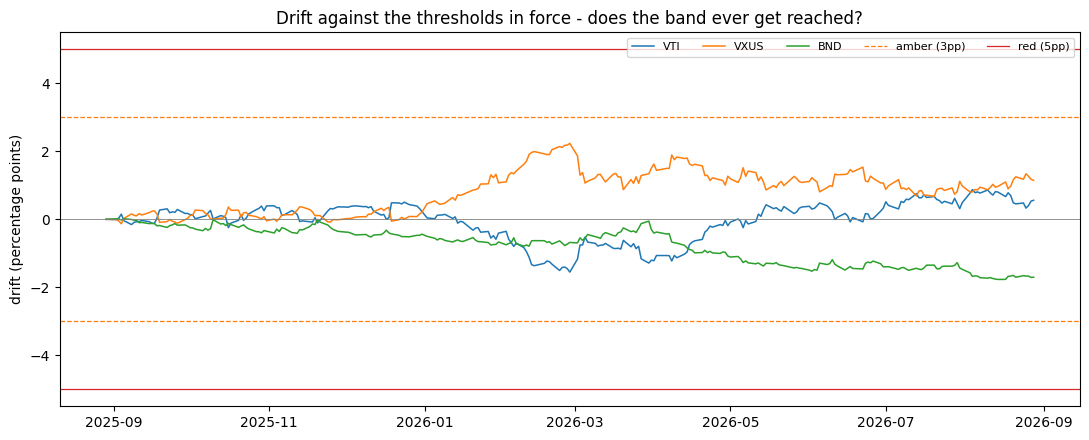

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for t in TICKERS:
    sub = drift_long[drift_long['ticker'] == t]
    ax.plot(sub['date'], sub['drift_pp'], linewidth=1.1, label=t)

for level, style, label in [(AMBER_PP, '--', 'amber'), (RED_PP, '-', 'red')]:
    for sign in (1, -1):
        ax.axhline(sign * level, linestyle=style, linewidth=0.9,
                   color='tab:orange' if label == 'amber' else 'tab:red',
                   label=f'{label} ({level:.0f}pp)' if sign == 1 else None)

ax.axhline(0, color='grey', linewidth=0.6)
ax.set_ylabel('drift (percentage points)')
ax.set_title('Drift against the thresholds in force - does the band ever get reached?')
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

### The alarm nobody has tested

A monitor that has never fired and a monitor that is broken produce the same
output: silence. Over a calm window they are indistinguishable, and "no alerts"
gets read as "nothing is wrong" when it might mean "nothing works".

So before drawing any conclusion from a quiet year, confirm the alarm is
physically capable of ringing. This injects a synthetic drift day past the red
line and checks the flag comes back red. It is a smoke test for the plumbing,
not a claim about the market.

In [26]:
checks = [
    outliers.stress_test_threshold(drift_long, shock_pp=6.0,
                                   amber=AMBER_PP, red=RED_PP),
    outliers.stress_test_threshold(drift_long, shock_pp=-5.5,
                                   amber=AMBER_PP, red=RED_PP),
    outliers.stress_test_threshold(drift_long, shock_pp=3.5,
                                   amber=AMBER_PP, red=RED_PP),
    outliers.stress_test_threshold(drift_long, shock_pp=0.4,
                                   amber=AMBER_PP, red=RED_PP),
]
stress = pd.DataFrame(checks)[['injected_pp', 'amber_pp', 'red_pp', 'flag', 'fires']]
print(stress.to_string(index=False))
print()

assert stress.loc[0, 'flag'] == 'red', 'a +6pp shock must read red'
assert stress.loc[1, 'flag'] == 'red', 'the rule must be symmetric in sign'
assert stress.loc[2, 'flag'] == 'amber', 'a 3.5pp shock sits in the amber band'
assert stress.loc[3, 'flag'] == 'green', 'a 0.4pp shock must stay green'
print('alarm wiring verified: the flag responds correctly at every level.')

 injected_pp  amber_pp  red_pp  flag  fires
         6.0       3.0     5.0   red   True
        -5.5       3.0     5.0   red   True
         3.5       3.0     5.0 amber  False
         0.4       3.0     5.0 green  False

alarm wiring verified: the flag responds correctly at every level.


The alarm works. That matters more than it sounds: it converts a year of silence
from *unknown* into *evidence*. The monitor is not broken - the portfolio simply
never drifted far enough to trip it.

In [27]:
# --- save the Stage 07 evidence ---
prof_path = PROC / f'drift_profile_{stamp}.csv'
sens_path = PROC / f'threshold_sensitivity_{stamp}.csv'
sus_path = PROC / f'return_outliers_{stamp}.csv'

profile.to_csv(prof_path)
sensitivity.to_csv(sens_path, index=False)
suspect[['date', 'ticker', 'close', 'ret',
         'ret_outlier_iqr', 'ret_outlier_z']].to_csv(sus_path, index=False)

for p in (prof_path, sens_path, sus_path):
    print('%-46s %6d bytes' % (p.name, p.stat().st_size))

drift_profile_20260830-1023.csv                   150 bytes
threshold_sensitivity_20260830-1023.csv           211 bytes
return_outliers_20260830-1023.csv                1608 bytes


### What Stage 07 changed, and what it deliberately did not

**Changed:** the monitor now has an outlier definition on both sides, stated in
`docs/outliers.md` - price-level faults judged per fund on daily returns, and
drift-level exceptions judged against a threshold that has now been priced
against a year of real data.

**Not changed: the 5pp red line stays where it is.** The tempting move after
seeing a year of green is to lower the threshold until something lights up. That
would be tuning the policy to flatter the output, which is backwards - the
threshold encodes what the firm principal considers worth acting on, and no
amount of quiet data changes that judgement. What the sweep does earn is the
right to *say* so: the line is high relative to this window, that is a deliberate
choice, and here is the number.

**The risk this leaves.** If the next year is not like this one, the first time
the alarm fires will be the first time anyone has seen it fire in production -
which is why the stress test above is committed alongside it rather than run
once and forgotten.

---

## Stage 08 - Exploratory Data Analysis

The full reasoning lives in `notebooks/eda.ipynb`. This section runs the three checks
that the rest of the pipeline depends on, and fails the run if any of them stops holding:

1. the date axis is business-daily, sorted, and free of duplicates and holes;
2. the drift is a trend rather than noise, which is what decides the Stage 09 feature set;
3. no column is silently degenerate before it becomes a feature.

In [28]:
# --- Stage 08 setup ---
from src import eda

daily_axis = weights_df.reset_index()[['date']]      # one row per trading day

# Profiling frame: drift_long plus the categorical columns, on a copy, so nothing
# Stage 07 built is mutated underneath it.
eda_frame = drift_long.copy()
eda_frame['flag'] = flag_drift(eda_frame['drift_pp'])
eda_frame['asset_class'] = np.where(eda_frame['ticker'] == 'BND', 'bond', 'equity')

print(f'profiling {len(eda_frame)} fund-days over {len(daily_axis)} trading days')
print(eda_frame['flag'].value_counts().to_string())

profiling 753 fund-days over 251 trading days
flag
green    753


In [29]:
# 1. Is the axis sound? Business-day grid, because a calendar grid reports every
#    weekend as a hole and buries the ten days that are genuinely absent.
axis = eda.time_axis_report(daily_axis, freq='B')

for key in ('n_unique_dates', 'is_sorted', 'n_duplicate_dates', 'n_missing_periods'):
    print(f'  {key:<20} {axis[key]}')
print('  absent business days:', ', '.join(str(d.date()) for d in axis['missing_periods']))

assert axis['is_sorted'],                  'dates are out of order - every lag downstream is wrong'
assert axis['n_duplicate_dates'] == 0,     'duplicate trading dates on the daily axis'
assert axis['n_missing_periods'] <= 12,    'more absent business days than a year of holidays'
print('axis OK')

  n_unique_dates       251
  is_sorted            True
  n_duplicate_dates    0
  n_missing_periods    10
  absent business days: 2025-09-01, 2025-11-27, 2025-12-25, 2026-01-01, 2026-01-19, 2026-02-16, 2026-04-03, 2026-05-25, 2026-06-19, 2026-07-03
axis OK


Ten absent business days, all US market holidays, against 114 absent *calendar* days.
That difference is the whole point of the check. The axis is business-daily, so a 7-row
rolling window in Stage 09 spans 9 calendar days on average and 11 across a holiday
weekend, and reindexing to `freq='D'` would insert 114 empty rows that dilute every
rolling statistic without raising an error. Stage 09 builds on this index as it is.

In [30]:
# 2. Trend or noise? Stage 07 established that neither threshold has ever fired.
#    A flag count cannot say whether that is a threshold set too high for the process,
#    or a trend that has not arrived yet. Those call for opposite responses.
trend = eda.drift_trend(drift_long, amber=AMBER_PP, red=RED_PP)
print(trend.to_string())

        n_obs  current_pp  rate_pp_per_year  corr_with_time  r_squared  years_to_amber  years_to_red
ticker                                                                                              
BND       251      -1.705            -1.688          -0.929      0.863           0.767         1.952
VTI       251       0.560             0.343           0.175      0.031           7.105        12.927
VXUS      251       1.145             1.345           0.643      0.413           1.379         2.866


In [31]:
# 3. Per-fund return profile - the evidence behind Stage 07 preferring IQR over z-score.
returns_profile = eda.return_profile(prices_clean)
print(returns_profile.to_string())

          n  mean_pct  std_pct  ann_vol_pct  min_pct  max_pct    skew  excess_kurtosis
ticker                                                                                
BND     250   -0.0079   0.2461       3.9074  -0.7999   0.5761 -0.2758           0.0656
VTI     250    0.0737   0.8231      13.0666  -2.6795   2.9293 -0.2229           1.1177
VXUS    250    0.0873   1.0711      17.0026  -3.7333   4.1143 -0.1243           2.0053


**Read these two tables together.** BND's drift correlates with time at -0.93: 86% of its
variation is a straight line, falling 1.69pp a year. VXUS rises 1.35pp a year. VTI is
flat. So the year of unbroken green is not a stationary process sitting safely below the
line, it is a one-way ratchet that has not travelled far enough yet. From today's drift,
BND is about 0.8 years from amber and VXUS about 1.4.

That changes the Stage 07 conclusion from a null result into a dated one, and it is the
single most useful sentence this project has produced for the principal.

The return profile is the other half. Excess kurtosis is measured against a normal
distribution, where 0 is the normal value. VXUS at 2.0 has heavier tails than normal,
which is exactly where a 3-sigma z-score assumes it knows the shape. BND at 0.07 is
near-normal. That is the evidence for Stage 07 making IQR the primary rule.

In [32]:
# 4. Anything degenerate before it becomes a feature?
flagged = eda.flag_columns(eda_frame)
print(flagged.to_string(index=False) if not flagged.empty
      else 'nothing flagged at the default thresholds')

# `flag` is 100% green, so it is a constant wearing a disguise. Assert that the check
# actually catches it: a flag_columns that silently returns nothing is worse than none.
assert (flagged['column'] == 'flag').any(), 'flag_columns missed the all-green column'
print()
print('confirmed: `flag` is a reporting column, not a Stage 09 feature')

column             issue  value  threshold
  flag dominant category  100.0       95.0

confirmed: `flag` is a reporting column, not a Stage 09 feature


In [33]:
# --- save the Stage 08 evidence ---
eda_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')
trend_path = PROC / f'eda_drift_trend_{eda_stamp}.csv'
retprof_path = PROC / f'eda_return_profile_{eda_stamp}.csv'

trend.to_csv(trend_path)
returns_profile.to_csv(retprof_path)

for p in (trend_path, retprof_path):
    print('%-46s %6d bytes' % (p.name, p.stat().st_size))

eda_drift_trend_20260830-1023.csv                 230 bytes
eda_return_profile_20260830-1023.csv              256 bytes


### What Stage 08 changed

**Nothing about the data.** No values were altered, dropped or imputed. That is the
correct outcome for an EDA stage, and it is worth stating rather than leaving implied.

**Two things about what comes next.**

Stage 09 now has a feature list with a reason attached to each entry: first difference of
drift, rolling 21-day and 63-day slope, the equity-minus-bond return spread, and 21-day
realized volatility. It also has two prohibitions. Do not build calendar features, because
there is no seasonality in this series. Do not reindex to `freq='D'`, because the axis is
business-daily and doing so silently dilutes every rolling window.

Stage 10b now knows its split will look bad and why. A chronological split trains on the
low-drift half and tests on the high-drift half, so the test set is out of distribution by
construction. A random split would score better and would be leakage. The split stays
chronological and the write-up reports the drift range of each side next to the score.

---

## Stage 09 - Feature Engineering

The reasoning behind each feature is in `docs/features.md`, and the definitions are in
`README.md`. This section builds the matrix, checks it, and fails the run if any of
three things stops being true:

1. no feature reads data from after the row it describes;
2. no column reaches the modelling set while it is constant or mostly missing;
3. the target is far enough ahead to be worth predicting.

In [34]:
# --- Stage 09 setup ---
from src import features as fe

HORIZON = 21          # trading days; the choice is justified two cells below
TARGET = f'y_absdrift_fwd_{HORIZON}'

# One call, from the cleaned prices alone. `raw_reloaded` is passed only so
# `close_was_filled` can compare observed against filled closes.
features = fe.build_feature_matrix(prices_clean, TARGET_WEIGHTS,
                                   prices_raw=raw_reloaded, horizon=HORIZON)

print('feature matrix:', features.shape)
print('columns       :', ', '.join(c for c in features.columns if c not in
                                   ('date', 'ticker', 'weight', 'target_weight')))
features.head()

feature matrix: (753, 21)
columns       : drift_pp, abs_drift, drift_rel, abs_drift_rel, drift_chg_1, drift_chg_5, drift_slope_21, drift_slope_63, ret_1, vol_21, eq_bond_spread_21, ticker_BND, ticker_VTI, ticker_VXUS, ticker_target, close_was_filled, y_absdrift_fwd_21


,date,ticker,weight,target_weight,drift_pp,abs_drift,drift_rel,abs_drift_rel,drift_chg_1,drift_chg_5,...,drift_slope_63,ret_1,vol_21,eq_bond_spread_21,ticker_BND,ticker_VTI,ticker_VXUS,ticker_target,close_was_filled,y_absdrift_fwd_21
0,2025-08-29,BND,0.100000,0.1,0.000000,0.000000,0.000000,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,1,0,0,0.1,0,0.200645
1,2025-09-02,BND,0.100140,0.1,0.014004,0.014004,0.140043,0.140043,0.014004,NaN,...,NaN,-0.005420,NaN,NaN,1,0,0,0.1,0,0.247308
2,2025-09-03,BND,0.100116,0.1,0.011644,0.011644,0.116437,0.116437,-0.002361,NaN,...,NaN,0.003270,NaN,NaN,1,0,0,0.1,0,0.251933
3,2025-09-04,BND,0.099806,0.1,-0.019356,0.019356,-0.193559,0.193559,-0.031000,NaN,...,NaN,0.003802,NaN,NaN,1,0,0,0.1,0,0.287480
4,2025-09-05,BND,0.100146,0.1,0.014556,0.014556,0.145557,0.145557,0.033912,NaN,...,NaN,0.004735,NaN,NaN,1,0,0,0.1,0,0.335618


In [35]:
# Why 21 days and not 1. Today's absolute drift against its own future value:
rows = []
base = fe.drift_features(fe.drift_panel(prices_clean, TARGET_WEIGHTS),
                         TARGET_WEIGHTS, slope_windows=())
for h in (1, 5, 21, 63):
    frame = fe.make_forward_target(base, horizon=h)
    pair = frame[['abs_drift', f'y_absdrift_fwd_{h}']].dropna()
    rows.append({'horizon_trading_days': h,
                 'r_with_todays_level': pair.iloc[:, 0].corr(pair.iloc[:, 1]),
                 'usable_rows': len(pair)})
horizon_choice = pd.DataFrame(rows).set_index('horizon_trading_days').round(3)
print(horizon_choice.to_string())

assert horizon_choice.loc[1, 'r_with_todays_level'] > 0.95, \
    'a 1-day horizon should be near-trivially predictable; if it is not, the trend broke'
assert horizon_choice.loc[HORIZON, 'r_with_todays_level'] < 0.80, \
    'the chosen horizon must leave something for the other features to explain'

                      r_with_todays_level  usable_rows
horizon_trading_days                                  
1                                   0.979          750
5                                   0.913          738
21                                  0.689          690
63                                  0.235          564


**Why the horizon is a decision and not a default.** Today's absolute drift predicts
tomorrow's at 0.98. A model trained on a one-day horizon would score above 0.95 by
answering "the same as today" and would have learned nothing. That is Stage 08's trend
finding arriving as a modelling constraint: a trended series is trivially predictable
one step ahead, and the triviality scales with how short the step is.

At 21 trading days the same correlation falls to 0.69, which leaves room for the other
features, and a month is enough warning for the principal to act on. The two assertions
above hold the choice in place: if a future pull breaks either bound, the horizon needs
revisiting rather than silently becoming a worse question.

In [36]:
# What each feature is worth, and what it costs. Coverage and distinctness come
# BEFORE the correlation on purpose: a promising number on a nearly empty column
# is not a result.
CANDIDATES = fe.MODEL_FEATURES + ['drift_slope_63', 'ticker_target', 'close_was_filled']
report = fe.feature_report(features, CANDIDATES, TARGET, group='ticker')
print(report.to_string())

                   pct_missing  n_unique     mean      std  n_pairs  corr_with_target  corr_BND  corr_VTI  corr_VXUS
feature                                                                                                             
abs_drift                 0.00       751   0.6789   0.5322      690            0.6890    0.8651    0.2734     0.6564
abs_drift_rel             0.00       751   3.7448   4.3977      690            0.6206    0.8651    0.2734     0.6564
drift_chg_1               0.40       750  -0.0000   0.1118      687           -0.0096   -0.0510   -0.0577     0.0374
drift_chg_5               1.99       738  -0.0000   0.2319      675           -0.0228   -0.0913   -0.1291     0.0820
drift_slope_21            7.97       693   0.0000   6.0407      630           -0.1084   -0.2395   -0.3866     0.1565
ret_1                     0.40       741   0.0005   0.0079      687           -0.0255   -0.0508   -0.0820     0.0062
vol_21                    8.37       690  11.2464   6.5540      

**The row that matters most is `vol_21`.** Pooled it correlates with the target at
+0.036, which reads as irrelevant. Per fund it is **+0.57 for BND and -0.23 for VTI**.
The pooled number is not a weak signal, it is two opposite signals cancelling.

That is the concrete payoff of the one-hot encoding. A model without the fund identity
would see +0.036, drop volatility, and be wrong about two funds at once. It is also the
sharpest illustration in this project of why correlation is a screen rather than a
ranking.

`abs_drift` at +0.689 is the strongest single feature and largely restates the trend.
`drift_chg_1` at -0.010 is the honest failure: Stage 08's written instruction put the
first difference at the top of the list, and it did not work. The information Stage 08
was pointing at lives in the smoothed rate, `drift_slope_21`, not the raw one. The
feature stays in the matrix as a recorded negative result rather than being deleted.

In [37]:
# 1. Does any feature read the future? Build on the full history, build again on a
#    truncated history, compare the overlap. A causal feature is identical in both.
#    `with_target=False` because a forward target is SUPPOSED to change.
audit = fe.assert_no_lookahead(
    lambda frame: fe.build_feature_matrix(frame, TARGET_WEIGHTS, with_target=False),
    prices_clean, fe.MODEL_FEATURES)

for key, value in audit.items():
    print(f'  {key:<18} {value}')
print('no look-ahead in any of the %d modelling features' % len(fe.MODEL_FEATURES))

  cut_date           2026-05-12 00:00:00
  rows_compared      528
  features_checked   11
no look-ahead in any of the 11 modelling features


In [38]:
# A test that never fails is not a test. Break one feature deliberately and confirm
# the audit catches it. A CENTRED window is the classic leak: it reads as an ordinary
# smoother and quietly sees ten days into its own future.
def _leaky(frame):
    out = fe.build_feature_matrix(frame, TARGET_WEIGHTS, with_target=False)
    out['drift_slope_21'] = (out.groupby('ticker')['drift_pp']
                                .transform(lambda s: s.rolling(21, center=True).mean()))
    return out


try:
    fe.assert_no_lookahead(_leaky, prices_clean, ['drift_slope_21'])
    raise RuntimeError('the look-ahead audit failed to catch a known leak')
except AssertionError as exc:
    print('leak correctly caught:')
    print(' ', exc)

leak correctly caught:
  look-ahead detected in 'drift_slope_21': truncating the future changed which past rows are even defined (30 NaN with the full history, 60 without it). A window that needs rows after t is not causal.


**Why this check earns its place in the pipeline.** A leaked feature does not raise an
error. It raises an R-squared, and everything about the code and the output continues to
look correct. `center=True` is a one-word change that a code review reads as a smoothing
preference and that lets every row see ten days of its own future. In Stage 10b it would
produce a test score that cannot be reproduced in production.

Running the audit here means a future edit that introduces a leak fails this notebook
rather than improving the model.

In [39]:
# 2. Does anything degenerate reach the modelling set? Stage 08's own gate, plus the
#    constant check that gate is known to miss.
gate = eda.flag_columns(features[CANDIDATES])
print(gate.to_string(index=False) if not gate.empty else 'gate: nothing flagged')

constants = [c for c in CANDIDATES if features[c].nunique(dropna=True) <= 1]
print('constant columns:', constants or 'none')

for column in fe.MODEL_FEATURES:
    assert features[column].nunique(dropna=True) > 1, f'{column} is constant'
    assert features[column].isna().mean() <= 0.20, f'{column} is more than 20% missing'
print('all %d modelling features pass the Stage 08 gate' % len(fe.MODEL_FEATURES))

        column            issue  value  threshold
drift_slope_63 high missingness   24.7       20.0
constant columns: ['close_was_filled']
all 11 modelling features pass the Stage 08 gate


**What the gate caught.** `drift_slope_63` at 24.70% missing, against Stage 08's 20%
threshold. It costs a quarter of the panel and returns a pooled correlation of -0.001,
so it is excluded. `ticker_freq` is not built here at all: with 251/251/251 rows per
fund, frequency encoding is arithmetically a constant, which the homework notebook
demonstrates rather than asserts.

**What it missed, and why that is worth knowing.** `close_was_filled` is constant at
zero on this pull, and `flag_columns` does not flag it. Its near-zero-variance rule
divides by the mean and skips any column whose mean is zero. The blind spot is narrow
and precise, all-zero columns only, and the explicit `nunique` assertions above cover it.

**`close_was_filled` is still built and still saved.** It is excluded from the modelling
set while it is constant, which is the correct handling today. It stays in the pipeline
because it costs one merge, it is verified to fire on a damaged copy in the homework
notebook, and on the day a vendor gap appears it is the only column that can tell a
model which rows are estimates rather than observations. This closes the item
`README.md` has carried open since Stage 06.

In [40]:
# --- save the Stage 09 artifacts ---
feat_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

model_ready = features[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET]].dropna()

full_path = PROC / f'features_full_{feat_stamp}.parquet'
ready_path = PROC / f'features_model_ready_{feat_stamp}.parquet'
rep_path = PROC / f'feature_report_{feat_stamp}.csv'

write_df(features, full_path)
write_df(model_ready, ready_path)
report.to_csv(rep_path)

lost = len(features) - len(model_ready)
print(f'full matrix : {features.shape}')
print(f'model ready : {model_ready.shape}  ({lost} rows lost to windows and the '
      f'{HORIZON}-day forward target)')
print()
for p in (full_path, ready_path, rep_path):
    print('%-52s %7d bytes' % (p.name, p.stat().st_size))

# Round trip, same as every other artifact in this project.
back = read_df(ready_path)
assert back.shape == model_ready.shape, 'round trip changed the shape'
print('round trip verified')

full matrix : (753, 21)
model ready : (627, 14)  (126 rows lost to windows and the 21-day forward target)

features_full_20260830-1023.parquet                    97828 bytes
features_model_ready_20260830-1023.parquet             63317 bytes
feature_report_20260830-1023.csv                         921 bytes
round trip verified


### What Stage 09 changed, and what it deliberately did not

**Eleven features, each traceable to a finding.** Not one was invented because it was
easy to compute. `abs_drift_rel` comes from Stage 07's open unit problem, the rate
features from Stage 08's trend, `vol_21` from Stage 08's volatility clustering,
`eq_bond_spread_21` from the mechanism Stage 08 identified, the one-hot encoding from
Stage 08's 251/251/251 categorical profile, and `close_was_filled` from this README's own
open item. That lineage is the deliverable; the code is the easy half.

**A unit result worth taking to the principal.** Drift measured relative to each fund's
target predicts its own future at **0.906**, against **0.689** for the percentage-point
formulation. Within a fund the two are the same number rescaled, so this is not a
better feature, it is evidence that the relative unit is the more coherent description
of what the portfolio does. Stage 07 raised the unit question and left it open. Stage 09
did not close it, because changing the unit changes the policy, but it is no longer an
open question without evidence attached.

**One prediction that failed, kept on the record.** Stage 08 said to build the first
difference of drift. Built, measured at -0.010, and reported. The idea was right and the
implementation was too raw: the signal is in `drift_slope_21`, not `drift_chg_1`.

**Nothing was scaled, and that is deliberate.** Standardising features here would fit the
scaler on the whole history, including the rows Stage 10b will hold out as a test set.
That is the same class of error as the centred window above, and the look-ahead audit
would *not* catch it, because it happens after the features are built. Scaling belongs
inside the split.

**Handoff to Stage 10.** `data/processed/features_model_ready_<stamp>.parquet`: 11
features, one target, complete rows only. Split chronologically, as Stage 08 required,
and expect a worse score than a random split would give, because a random split on a
trended series leaks.

---

## Stage 10a - Modeling: Linear Regression

The first model this project has fitted. Reasoning and full diagnostics are in
`docs/modeling.md`; the run with every plot is `notebooks/modeling_regression.ipynb`.
This section fits it, checks it, and fails the run if any of three things stops holding:

1. the design matrix is full rank, so standard errors are defined at all;
2. the model beats persistence, the baseline it has to beat to be worth anything;
3. the independence assumption is still as broken as documented, because the whole
   interpretation depends on that number.

**Track:** regression. Classification was rejected on the data, not on preference: the
flag is green on all 753 fund-days, so a classifier at the 3pp threshold has zero
positive cases.

In [41]:
# --- Stage 10a setup ---
from src import modeling as md

HORIZON_10A = 21
TARGET_10A = f'y_absdrift_fwd_{HORIZON_10A}'

model_data = (features[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET_10A]]
              .dropna().sort_values(['ticker', 'date']).reset_index(drop=True))
model_data['abs_drift_sq'] = model_data['abs_drift'] ** 2
model_data['vol_x_absdrift'] = model_data['vol_21'] * model_data['abs_drift']

# Stage 09 built three one-hot columns and left drop_first as a Stage 10 decision.
# Three indicators sum to 1 on every row, which duplicates the intercept.
FEATURES_10A = [c for c in fe.MODEL_FEATURES if c != 'ticker_BND']   # BND = reference

_full = np.column_stack([np.ones(len(model_data)),
                         model_data[fe.MODEL_FEATURES].to_numpy(float)])
_drop = np.column_stack([np.ones(len(model_data)),
                         model_data[FEATURES_10A].to_numpy(float)])
print('all three dummies: %d cols, rank %d' % (_full.shape[1], np.linalg.matrix_rank(_full)))
print('BND dropped      : %d cols, rank %d' % (_drop.shape[1], np.linalg.matrix_rank(_drop)))
assert np.linalg.matrix_rank(_drop) == _drop.shape[1], 'design matrix is still rank deficient'

train_10a, test_10a, cut_10a = md.chronological_split(model_data, test_frac=0.2)
print()
print('cut %s | train %d rows | test %d rows'
      % (cut_10a.date(), len(train_10a), len(test_10a)))
print('train target mean %.3f range %.3f-%.3f'
      % (train_10a[TARGET_10A].mean(), train_10a[TARGET_10A].min(), train_10a[TARGET_10A].max()))
print('test  target mean %.3f range %.3f-%.3f'
      % (test_10a[TARGET_10A].mean(), test_10a[TARGET_10A].min(), test_10a[TARGET_10A].max()))

all three dummies: 12 cols, rank 11
BND dropped      : 11 cols, rank 11

cut 2026-06-01 | train 501 rows | test 126 rows
train target mean 0.726 range 0.002-2.233
test  target mean 1.033 range 0.305-1.769


In [42]:
# Fit, and score against the baselines. The persistence row is the honest benchmark:
# it does nothing but assume today's drift still holds in a month.
fit_10a = md.fit_ols(train_10a[FEATURES_10A].to_numpy(),
                     train_10a[TARGET_10A].to_numpy(), FEATURES_10A)
pred_10a = md.predict_ols(fit_10a['beta'], test_10a[FEATURES_10A].to_numpy())

scores_10a = md.evaluate(test_10a[TARGET_10A], pred_10a)
base_10a = md.compare_baselines(train_10a, test_10a, TARGET_10A, naive_col='abs_drift')

board_10a = pd.DataFrame([
    {'predictor': 'linear regression', **scores_10a},
    {'predictor': 'persistence (today)', **base_10a['persistence']},
    {'predictor': 'train mean (flat line)', **base_10a['train_mean']},
]).set_index('predictor').round(4)
print(board_10a.to_string())
print()
print('train R2 %.4f | adjusted %.4f | parameters %d'
      % (fit_10a['r_squared'], fit_10a['adj_r_squared'], fit_10a['k']))

assert scores_10a['rmse'] < base_10a['persistence']['rmse'], \
    'the model does not beat persistence - it is not worth reporting'

                            r2    rmse     mae    n
predictor                                          
linear regression       0.6917  0.2333  0.1915  126
persistence (today)     0.5024  0.2964  0.2372  126
train mean (flat line) -0.5331  0.5203  0.4037  126

train R2 0.4578 | adjusted 0.4468 | parameters 11


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

**Read the middle row first.** Persistence reaches R² 0.502 by assuming nothing changes.
The model's contribution is the gap: RMSE 0.233 against 0.296, about 21% better. Quoting
R² 0.692 on its own would present a model that has largely learned the trend as a model
that has learned something.

RMSE 0.233 is percentage points of drift, against a 3pp amber threshold and a worst
observed drift of 2.23pp. A typical error is roughly a tenth of the range the monitor
cares about.

In [43]:
# The four assumptions. This is the part that decides what the model may be used for.
diag_10a = md.regression_diagnostics(fit_10a, train_10a[FEATURES_10A].to_numpy(),
                                     group_labels=train_10a['ticker'], horizon=HORIZON_10A)

print('1. LINEARITY        curvature %+.4f (residual sd %.3f)'
      % (diag_10a['linearity']['quadratic_curvature'], fit_10a['residuals'].std()))
print('2. INDEPENDENCE     2.0 = independent')
for g, v in diag_10a['independence']['by_group'].items():
    print('     %-5s Durbin-Watson %.3f   lag-1 autocorrelation %+.3f'
          % (g, v['durbin_watson'], v['lag1_autocorr']))
h = diag_10a['homoscedasticity']
print('3. HOMOSCEDASTICITY Breusch-Pagan p %.2e, spread ratio %.2f' % (h['p_value'], h['ratio']))
n = diag_10a['normality']
print('4. NORMALITY        Shapiro p %.2e, skew %+.3f, excess kurtosis %+.3f'
      % (n['shapiro_p'], n['skew'], n['excess_kurtosis']))

eff = diag_10a['effective_sample']
print()
print('THE BINDING CONSTRAINT')
print('  %d rows / %d funds = %.0f per fund; / %d-day horizon = %.1f effective per fund'
      % (eff['n_rows'], eff['n_groups'], eff['rows_per_group'],
         eff['horizon'], eff['effective_per_group']))
print('  effective observations %.0f  vs  %d parameters  =  %.1f per parameter'
      % (eff['effective_total'], fit_10a['k'], eff['effective_total'] / fit_10a['k']))

# The interpretation depends on this being broken. If it ever stops being broken,
# the write-up in docs/modeling.md is wrong and should fail the run rather than mislead.
assert diag_10a['independence']['pooled_durbin_watson'] < 0.5, \
    'residual autocorrelation has changed - docs/modeling.md needs revisiting'

1. LINEARITY        curvature -0.0319 (residual sd 0.383)
2. INDEPENDENCE     2.0 = independent
     BND   Durbin-Watson 0.107   lag-1 autocorrelation +0.947
     VTI   Durbin-Watson 0.151   lag-1 autocorrelation +0.924
     VXUS  Durbin-Watson 0.114   lag-1 autocorrelation +0.943
3. HOMOSCEDASTICITY Breusch-Pagan p 3.33e-16, spread ratio 1.16
4. NORMALITY        Shapiro p 2.05e-08, skew +0.588, excess kurtosis +0.244

THE BINDING CONSTRAINT
  501 rows / 3 funds = 167 per fund; / 21-day horizon = 8.0 effective per fund
  effective observations 24  vs  11 parameters  =  2.2 per parameter


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:179: RuntimeWarning: divide by zero encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:179: RuntimeWarning: overflow encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:179: RuntimeWarning: invalid value encountered in matmul
  beta = np.linalg.solve(design.T @ design, design.T @ g)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:180: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:180: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:180: RuntimeW

**Independence fails, structurally.** Durbin-Watson 0.107 to 0.151 where 2.0 means
independent, and lag-1 residual autocorrelation +0.92 to +0.95.

The cause is the target, not the model. Absolute drift 21 trading days ahead means two
consecutive rows share **20 of the 21 days** in their windows: nearly the same observation
counted twice. So 501 rows carry about **24 independent observations** supporting **11
parameters**, roughly two per parameter.

Autocorrelation does not bias coefficients; it biases standard errors downward. Every
p-value this model reports assumes 501 independent observations. **The point predictions
stand. The inference does not**, and no coefficient here can support a claim that a factor
drives drift.

The other three are minor by comparison. Linearity broadly holds. Homoscedasticity fails
at p = 3e-16 but the residual spread ratio is only 1.16, statistically certain and
practically small. Normality's right skew is what an absolute value bounded at zero
produces.

In [44]:
# "Automate the modeling process so you can auto-try the model with some variations."
# Train and test side by side, because overfitting is only visible when both are shown.
VARIANTS_10A = {
    'baseline (all 10)':       FEATURES_10A,
    'drift only':              ['abs_drift', 'abs_drift_rel', 'drift_chg_1',
                                'drift_chg_5', 'drift_slope_21'],
    'no fund dummies':         [c for c in FEATURES_10A if not c.startswith('ticker_')],
    'abs_drift alone':         ['abs_drift'],
    '+ abs_drift squared':     FEATURES_10A + ['abs_drift_sq'],
    '+ squared + interaction': FEATURES_10A + ['abs_drift_sq', 'vol_x_absdrift'],
}
sweep_10a, fits_10a = md.auto_try(train_10a, test_10a, TARGET_10A,
                                  VARIANTS_10A, horizon=HORIZON_10A)
print(sweep_10a.to_string())
print()
print('best by test RMSE:', sweep_10a.index[0])

                         n_features  train_r2  test_r2  train_rmse  test_rmse  test_mae  overfit_gap  durbin_watson
variant                                                                                                            
drift only                        5    0.3820   0.7474      0.4091     0.2112    0.1759      -0.3653         0.1052
no fund dummies                   8    0.3851   0.7284      0.4081     0.2190    0.1832      -0.3433         0.1096
baseline (all 10)                10    0.4578   0.6917      0.3832     0.2333    0.1915      -0.2338         0.1277
+ abs_drift squared              11    0.4915   0.6015      0.3711     0.2653    0.2114      -0.1100         0.1466
abs_drift alone                   1    0.3624   0.5404      0.4156     0.2849    0.2388      -0.1780         0.1034
+ squared + interaction          12    0.5015   0.4943      0.3674     0.2988    0.2343       0.0073         0.1588

best by test RMSE: drift only


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

**Train R² rises with every feature added; test R² peaks at five and falls away.** That is
overfitting, measured rather than asserted, and it is what about 24 effective observations
predicts.

The five-feature model wins on both metrics: test R² 0.747 and RMSE 0.211pp, against the
full set's 0.692 and 0.233pp. Stage 09 called 627 rows over 11 features "roughly 63 rows
per feature, enough for a regularised linear model". That arithmetic used the wrong
numerator, and this table is the shortage seen from outside.

The polynomial term made things worse, not better. The mild curvature in the residual plot
was noise, and a squared term absorbed it at a cost of 0.09 test R². Recorded as a negative
result rather than swapped for a transformation that happened to work.

In [45]:
# --- save the Stage 10a evidence ---
model_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

sweep_10a.to_csv(PROC / f'model_variant_sweep_{model_stamp}.csv')
fit_10a['coefficients'].round(4).to_csv(PROC / f'model_coefficients_{model_stamp}.csv')
board_10a.to_csv(PROC / f'model_vs_baselines_{model_stamp}.csv')

preds_10a = test_10a[['date', 'ticker', TARGET_10A]].copy()
preds_10a['predicted'] = pred_10a
preds_10a['residual'] = preds_10a[TARGET_10A] - preds_10a['predicted']
preds_10a.to_csv(PROC / f'model_test_predictions_{model_stamp}.csv', index=False)

for p in sorted(PROC.glob(f'model_*{model_stamp}*')):
    print('%-52s %7d bytes' % (p.name, p.stat().st_size))

model_coefficients_20260830-1023.csv                     452 bytes
model_test_predictions_20260830-1023.csv                9295 bytes
model_variant_sweep_20260830-1023.csv                    506 bytes
model_vs_baselines_20260830-1023.csv                     161 bytes


### What Stage 10a changed, and what it deliberately did not

**A correction to Stages 08 and 09.** Both recorded the expectation that a chronological
split would score worse than a random one. Measured, it scored **better**: test R² 0.692
against 0.378, and better than its own training R² of 0.458. The reasoning assumed "out of
distribution" meant "harder"; the late period is where the trend is most established, so
the target there is narrower and easier. `docs/eda.md` and `docs/features.md` have been
amended. This does not make a random split safe, and its 0.378 is the evidence for that.

**A correction to Stage 09's feature count.** Eleven features was too many. The sweep
prefers five, and the reason is the effective sample size rather than anything about the
features themselves.

**Nothing was scaled, deliberately.** Standardising here would fit the scaler on rows a
future split will hold out. That is a leak the Stage 09 look-ahead audit cannot catch,
because it happens after the features are built. Scaling belongs inside a pipeline, which
is Stage 10b's requirement.

**The thresholds were not touched.** Stage 07 set amber at 3pp and red at 5pp; Stage 08
found neither has fired; Stage 10a still cannot say when one will, because the model
predicts a magnitude and has never seen an exceedance.

**Handoff to Stage 10b.** Same data, time-aware pipeline, lag and rolling features, and
the scaling avoided here fitted inside the split. The `sklearn` Pipeline is required as
committed repo code there, not just a notebook cell.

---

## Stage 10b - Modeling: Time Series

Full reasoning in `docs/timeseries.md`, the run with every plot in
`notebooks/modeling_timeseries.ipynb`. This section builds the lag features, fits the
Pipeline, and fails the run if any of three things stops holding:

1. no feature reads data from after the row it describes;
2. cross-validation still prefers a small model to the full feature set;
3. the forecast still beats persistence, the baseline it has to beat to be worth anything.

**Track: time series.** With Stage 10a's regression, both available tracks are now
committed. Classification remains unavailable: the flag is green on all 753 fund-days.

In [46]:
# --- Stage 10b setup ---
from src import timeseries as ts
from sklearn.linear_model import Ridge

HORIZON_10B = 21

ts_panel = fe.drift_panel(prices_clean, TARGET_WEIGHTS)
ts_panel['abs_drift'] = ts_panel['drift_pp'].abs()

# Features on ABSOLUTE drift, matching the target. Built on the signed series instead,
# the identical pipeline scores R2 -2.11, worse than predicting a constant.
ts_featured, TS_FEATURES = ts.make_lag_features(ts_panel, col='abs_drift')
ts_featured = ts.make_forecast_target(ts_featured, col='abs_drift', horizon=HORIZON_10B)
ts_data = ts_featured.dropna(subset=TS_FEATURES + ['y']).reset_index(drop=True)

print('lag/rolling features:', ', '.join(TS_FEATURES))
print('rows: %d of %d after windows and the %d-day target'
      % (len(ts_data), len(ts_featured), HORIZON_10B))

lag/rolling features: lag_1, lag_5, lag_21, roll_mean_5, roll_std_5, roll_mean_21, roll_std_21, roll_min_21, roll_max_21, momentum_21, zscore_21
rows: 624 of 753 after windows and the 21-day target


In [47]:
# 1. Causality. Every rolling statistic is shifted by one after its window; this checks
#    that claim rather than trusting it.
def _build_ts(price_frame):
    p = fe.drift_panel(price_frame, TARGET_WEIGHTS)
    p['abs_drift'] = p['drift_pp'].abs()
    out, _ = ts.make_lag_features(p, col='abs_drift')
    return out

ts_audit = fe.assert_no_lookahead(_build_ts, prices_clean, TS_FEATURES)
print('look-ahead audit passed on %d features, %d rows compared'
      % (ts_audit['features_checked'], ts_audit['rows_compared']))

look-ahead audit passed on 11 features, 528 rows compared


In [48]:
# 2. Walk-forward selection, on the training data only.
ts_train, ts_test, ts_cut = md.chronological_split(ts_data, test_frac=0.2)

TS_SETS = {
    'lag_1 only':        ['lag_1'],
    'lag_1 + zscore_21': ['lag_1', 'zscore_21'],
    'lag_1 + lag_5':     ['lag_1', 'lag_5'],
    'all 11 features':   TS_FEATURES,
}
ts_sweep = ts.sweep_feature_sets(ts_train, ts_test, 'y', TS_SETS)
print(ts_sweep.to_string())

ts_choice = ts_sweep.index[0]
print()
print('CV-selected:', ts_choice)

assert ts_sweep.loc[ts_choice, 'n_features'] < len(TS_FEATURES), \
    'cross-validation now prefers the full feature set - docs/timeseries.md needs revisiting'

                   n_features  cv_rmse  cv_std  test_rmse  test_mae  test_r2
lag_1 only                1.0   0.4666  0.1067     0.2857    0.2390   0.5376
lag_1 + lag_5             2.0   0.4739  0.0993     0.2833    0.2375   0.5454
lag_1 + zscore_21         2.0   0.4745  0.1104     0.2732    0.2287   0.5774
all 11 features          11.0   0.7463  0.5452     0.4087    0.3226   0.0540

CV-selected: lag_1 only


/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/annacui/miniforge3/envs/bootcamp_env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

In [49]:
# 3. Fit the chosen Pipeline and score it against persistence.
ts_pipe = ts.build_pipeline(model=Ridge(alpha=1.0)).fit(
    ts_train[TS_SETS[ts_choice]], ts_train['y'])
ts_pred = ts_pipe.predict(ts_test[TS_SETS[ts_choice]])

ts_board = pd.DataFrame([
    {'predictor': f'pipeline, {ts_choice}', **ts.evaluate_forecast(ts_test['y'], ts_pred)},
    {'predictor': 'persistence (no model)',
     **ts.evaluate_forecast(ts_test['y'], ts.persistence_forecast(ts_test))},
    {'predictor': 'train mean (flat line)',
     **ts.evaluate_forecast(ts_test['y'], np.full(len(ts_test), ts_train['y'].mean()))},
]).set_index('predictor').round(4)
print(ts_board.to_string())

ts_scores = ts.evaluate_forecast(ts_test['y'], ts_pred)
ts_naive = ts.evaluate_forecast(ts_test['y'], ts.persistence_forecast(ts_test))
assert ts_scores['rmse'] < ts_naive['rmse'], \
    'the forecast no longer beats persistence - it is not worth reporting'
print()
print('improvement on persistence: %.1f%% of RMSE'
      % (100 * (1 - ts_scores['rmse'] / ts_naive['rmse'])))

                           mae    rmse      r2    n
predictor                                          
pipeline, lag_1 only    0.2390  0.2857  0.5376  126
persistence (no model)  0.2392  0.2947  0.5081  126
train mean (flat line)  0.4024  0.5187 -0.5235  126

improvement on persistence: 3.1% of RMSE


**MAE 0.239pp, RMSE 0.286pp, against persistence at 0.295pp.** A 3% improvement.

The lag and rolling family is the standard time-series toolkit, and on this series it
recovers the naive baseline and little more. **Stage 10a's engineered features reached
0.211pp**, 26% better, using no lags at all. The signal here lives in features built from
domain reasoning (drift relative to target, the rolling slope of the trend, realized
volatility, fund identity) rather than in the series' own history.

That comparison is the most useful thing Stage 10b produced. What it adds is not accuracy
but discipline: a Pipeline that makes train-only fitting structural, a walk-forward split,
and a selection made on cross-validation rather than on the test set. Stage 10a's numbers
were produced without that discipline, which is why Stage 11 should re-check them under it.

In [50]:
# --- save the Stage 10b evidence ---
ts_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')
ts_sweep.to_csv(PROC / f'ts_feature_sweep_{ts_stamp}.csv')
ts_board.to_csv(PROC / f'ts_vs_baselines_{ts_stamp}.csv')

ts_out = ts_test[['date', 'ticker', 'y']].copy()
ts_out['predicted'] = ts_pred
ts_out['residual'] = ts_out['y'] - ts_out['predicted']
ts_out.to_csv(PROC / f'ts_test_predictions_{ts_stamp}.csv', index=False)

for p in sorted(PROC.glob(f'ts_*{ts_stamp}*')):
    print('%-52s %7d bytes' % (p.name, p.stat().st_size))

ts_feature_sweep_20260830-1023.csv                       268 bytes
ts_test_predictions_20260830-1023.csv                   9249 bytes
ts_vs_baselines_20260830-1023.csv                        168 bytes


### What Stage 10b changed, and what it deliberately did not

**Both modelling tracks are now committed.** Regression in 10a, time series here. The
instructions require at least one.

**The Pipeline is repo code, not a notebook cell.** `src/timeseries.py` builds it, which
is what makes train-only fitting a property of the project rather than of one execution.

**The scaling Stage 10a refused to do is now done, inside the split.** Measured, the leak
it prevents is worth 0.00001 RMSE on this data, and the notebook explains why that is
small (standardising is affine and a linear model absorbs it) rather than claiming a
victory. The guarantee is still worth having, because it stops being free the moment the
estimator changes.

**No threshold, feature or policy was changed.** Stage 07 set amber at 3pp and red at 5pp;
neither has fired; Stage 10b still cannot say when one will, because it forecasts a
magnitude and has never seen an exceedance.

**Into Stage 11.** Evaluation under uncertainty. Bootstrap the intervals Stage 10a could
not honestly quote, compare scenarios, and test whether the three funds are different
enough to need separate models. The fold-to-fold spread here is the first evidence that
they might be.

---

## Stage 11 - Evaluation and Risk Communication

Reasoning in `docs/evaluation.md`, the full run in `notebooks/evaluation.ipynb`. This
section quantifies the uncertainty Stage 10a refused to quote, and fails the run if any of
three things stops holding:

1. the block bootstrap still degenerates at the block length the target requires, which is
   the constraint the write-up rests on;
2. the prediction interval is still far wider than the confidence interval, which decides
   what the monitor publishes;
3. the per-fund bias is still detectable, because the correction depends on it.

In [51]:
# --- Stage 11 setup ---
from src import evaluation as ev

SEED_11, N_BOOT_11, LEVEL_11 = 111, 2000, 0.95
np.random.seed(SEED_11)

# The Stage 10a model, already fitted above. Nothing new is modelled here.
resid_11 = test_10a[TARGET_10A].to_numpy() - pred_10a

print('test %d rows over %d dates' % (len(test_10a), test_10a['date'].nunique()))
print('MAE %.4f | RMSE %.4f | bias %+.4f pp'
      % (ev.mae(resid_11), ev.rmse(resid_11), ev.bias(resid_11)))

test 126 rows over 42 dates
MAE 0.1915 | RMSE 0.2333 | bias +0.0951 pp


In [52]:
# 1. How wide is the honest interval, and can this window even measure it?
iid_11 = ev.iid_bootstrap(resid_11, ev.mae, n_boot=N_BOOT_11, seed=SEED_11, level=LEVEL_11)
sweep_11 = ev.block_length_sweep(test_10a, resid_11, ev.mae,
                                 blocks=(1, 3, 5, 10, 21, 42),
                                 n_boot=N_BOOT_11, seed=SEED_11, level=LEVEL_11)
print('iid 95%% CI [%.4f, %.4f] width %.4f' % (iid_11['lo'], iid_11['hi'], iid_11['width']))
print()
print(sweep_11.to_string())

# The write-up says the estimator degenerates at the block length the 21-day target needs.
# If that stops being true the constraint has lifted and docs/evaluation.md is wrong.
assert sweep_11.loc[42, 'n_distinct_starts'] == 1, \
    'the 42-day block is no longer degenerate - the test window has grown'
assert sweep_11.loc[5, 'width'] > sweep_11.loc[21, 'width'], \
    'width no longer collapses past block 5 - re-read docs/evaluation.md section 2'

iid 95% CI [0.1696, 0.2165] width 0.0469

            blocks_per_draw  n_distinct_starts      lo      hi   width
block_days                                                            
1                        42                 42  0.1694  0.2136  0.0442
3                        14                 40  0.1608  0.2242  0.0634
5                         9                 38  0.1630  0.2271  0.0641
10                        5                 33  0.1804  0.2245  0.0441
21                        2                 22  0.1849  0.2173  0.0324
42                        1                  1  0.1915  0.1915  0.0000


In [53]:
# 2. Which interval should the monitor publish?
cmp_11 = ev.interval_comparison(resid_11, levels=(0.80, 0.95, 0.99))
g_11 = ev.gaussian_intervals(resid_11, LEVEL_11)
e_11 = ev.empirical_intervals(resid_11, LEVEL_11)

print(cmp_11.to_string())
print()
print('confidence +/- %.4f pp | prediction +/- %.4f pp | ratio %.1fx'
      % (g_11['ci_half_width'], g_11['pi_half_width'], g_11['pi_over_ci']))
print('residual skew %+.3f | excess kurtosis %+.3f' % (e_11['skew'], e_11['excess_kurtosis']))

assert g_11['pi_half_width'] > 5 * g_11['ci_half_width'], \
    'the prediction and confidence intervals have converged - re-check which one to publish'

       gaussian_pi  empirical_pi   ratio  gaussian_ci
level                                                
0.80        0.2742        0.2761  1.0072       0.0244
0.95        0.4193        0.3835  0.9146       0.0374
0.99        0.5510        0.5102  0.9260       0.0491

confidence +/- 0.0374 pp | prediction +/- 0.4193 pp | ratio 11.2x
residual skew -0.242 | excess kurtosis -0.182


In [54]:
# 3. Is the pooled model fair to each fund?
sub_11 = ev.subgroup_report(test_10a, resid_11, group='ticker', block=10,
                            n_boot=N_BOOT_11, seed=SEED_11, level=LEVEL_11)
print(sub_11.to_string())

biased = sub_11.index[sub_11['bias_excludes_zero']].tolist()
print()
print('funds with bias intervals excluding zero:', biased or 'none')

assert biased, \
    'per-fund bias is no longer detectable - the Stage 12 correction may be unnecessary'

         n     mae  mae_lo  mae_hi    bias  bias_lo  bias_hi  bias_excludes_zero  bias_share_of_mae
ticker                                                                                             
BND     42  0.1691  0.0955  0.2321  0.1340   0.0514   0.2228                True             0.7923
VTI     42  0.2459  0.2138  0.3369  0.2147   0.1691   0.3365                True             0.8735
VXUS    42  0.1597  0.0984  0.2294 -0.0634  -0.2080   0.0267               False             0.3971

funds with bias intervals excluding zero: ['BND', 'VTI']


**Three results, in order of what they change.**

**The monitor must publish a prediction interval, not a confidence interval.** They are
0.037pp and 0.419pp, a factor of 11. The confidence interval answers "where is the average
relationship", and Dana reads one fund on one day.

**The pooled model is systematically biased for VTI (+0.215pp) and BND (+0.134pp)**, with
bias intervals excluding zero under a block bootstrap. For VTI, 87% of the total error is
that fixed offset rather than noise, so more data will not fix it. This is the
pooled-coefficient damage Stage 08 predicted from `vol_21` correlating +0.57 for BND and
-0.23 for VTI.

**Every interval here is a floor.** Acknowledging dependence widens the interval about 45%
at block 5, but the 21-day block the target actually requires has only 22 start positions
in a 42-day window, and the 42-day block has exactly one. The test window is too short to
bound its own uncertainty at the timescale that matters.

Also measured, and mildly reassuring: residual excess kurtosis is **-0.18**, so the
Gaussian interval is slightly conservative rather than optimistic. That is the opposite of
the usual fat-tail worry and it had to be checked rather than assumed.

In [55]:
# --- save the Stage 11 evidence ---
eval_stamp = dt.datetime.now().strftime('%Y%m%d-%H%M')

sweep_11.to_csv(PROC / f'eval_block_sweep_{eval_stamp}.csv')
cmp_11.to_csv(PROC / f'eval_intervals_{eval_stamp}.csv')
sub_11.to_csv(PROC / f'eval_subgroups_{eval_stamp}.csv')

latest_11 = test_10a.sort_values('date').groupby('ticker').tail(1)
point_11 = md.predict_ols(fit_10a['beta'], latest_11[FEATURES_10A].to_numpy())
fcst_11 = ev.prediction_interval(point_11, resid_11, level=LEVEL_11)
fcst_11.insert(0, 'fund', latest_11['ticker'].to_numpy())
fcst_11['bias_corrected'] = fcst_11['point'] + fcst_11['fund'].map(sub_11['bias'])
fcst_11['amber_in_interval'] = fcst_11['hi'] >= AMBER_PP
fcst_11.to_csv(PROC / f'eval_forecast_{eval_stamp}.csv', index=False)

print(fcst_11.round(3).to_string(index=False))
print()
print('widest upper bound %.3f pp against amber %.1f pp' % (fcst_11['hi'].max(), AMBER_PP))
for p in sorted(PROC.glob(f'eval_*{eval_stamp}*')):
    print('%-52s %7d bytes' % (p.name, p.stat().st_size))

fund  point    lo    hi  bias_corrected  amber_in_interval
 VTI  0.364 0.035 0.802           0.579              False
 BND  1.433 1.103 1.870           1.567              False
VXUS  1.036 0.706 1.473           0.973              False

widest upper bound 1.870 pp against amber 3.0 pp
eval_block_sweep_20260830-1023.csv                       225 bytes
eval_forecast_20260830-1023.csv                          306 bytes
eval_intervals_20260830-1023.csv                         145 bytes
eval_subgroups_20260830-1023.csv                         270 bytes


### What Stage 11 changed

**The monitor can now make a forward-looking statement with a bound on it.** In 21 trading
days BND sits at 1.43pp, VXUS at 1.04pp, VTI at 0.36pp, and the widest upper bound across
all three is 1.87pp against an amber line of 3pp. No fund is expected to need attention
within the month, and that conclusion survives the uncertainty rather than resting on a
point estimate.

**Two things were found that should change the model before Stage 12.** The per-fund bias
needs correcting, with interactions rather than a pooled fit. And the interval published
must be the prediction interval.

**One long-open question can now be closed for the principal.** The threshold unit does not
change the model's value: 25.8% improvement over persistence in percentage points, 25.6% in
relative units. Stage 07 raised it, Stage 09 added evidence, and Stage 11 can now say the
modelling side is indifferent, so it can be decided operationally.

**Nothing about the data, the thresholds or the features was changed.** Stage 11 measures;
it does not adjust.

**Into Stage 12.** The stakeholder-facing write-up. The material is now in place: a
forecast with an interval, a named bias to correct, an explicit list of what the result
holds under, and a monitoring plan for production.

---

# Stage 12 - Results Reporting and Delivery Design

Eleven stages produced a model. This section produces the **decision**, and settles the
one instruction Stage 11 handed forward that turned out to be impossible to carry out.

Full working: `notebooks/delivery.ipynb`. Reasoning: `docs/reporting.md`.

In [56]:
# --- Stage 12 setup ---
from src import reporting as rp

REPORTS_12 = ROOT / 'reports' if 'ROOT' in dir() else Path('reports')
IMG_12 = REPORTS_12 / 'images'
IMG_12.mkdir(parents=True, exist_ok=True)

FULL_12 = [c for c in fe.MODEL_FEATURES if c != 'ticker_BND']
FIVE_12 = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']
SEED_12, N_BOOT_12, LEVEL_12 = 111, 2000, 0.95
ORDER_12 = rp.DISPLAY_ORDER

print('stage 12 | seed %d | %d resamples | level %.2f' % (SEED_12, N_BOOT_12, LEVEL_12))

stage 12 | seed 111 | 2000 resamples | level 0.95


## 12.1 Stage 11 asked for per-fund interactions. They do not exist.

Two independent rank failures, one cause: `abs_drift_rel` is `abs_drift` divided by the
target weight, which makes it that interaction already.

In [57]:
recon_12 = model_data['abs_drift'] / model_data['ticker'].map(TARGET_WEIGHTS)
print('max |abs_drift_rel - abs_drift / weight| = %.2e'
      % float((model_data['abs_drift_rel'] - recon_12).abs().max()))

try:
    rp.fund_interactions(train_10a, FULL_12, ['abs_drift'])
except ValueError as e:
    print('guard:', str(e).split(':')[0])

r11_train_12 = (train_10a[TARGET_10A].to_numpy()
                - md.predict_ols(fit_10a['beta'], train_10a[FULL_12].to_numpy()))
print()
print('in-sample bias by fund (11-param):',
      {t: round(float(r11_train_12[(train_10a['ticker'] == t).to_numpy()].mean()), 9)
       for t in ORDER_12})
print('Zero by construction, so the test bias is out-of-sample drift, not misfit.')
print()

shift_12 = rp.regime_shift(train_10a, test_10a, TARGET_10A)
print(shift_12.to_string())

max |abs_drift_rel - abs_drift / weight| = 1.78e-15
guard: ['abs_drift'] cannot be interacted with the fund while 'abs_drift_rel' is in the model

in-sample bias by fund (11-param): {'VTI': 0.0, 'VXUS': 0.0, 'BND': -0.0}
Zero by construction, so the test bias is out-of-sample drift, not misfit.

        train_mean  test_mean   shift
ticker                               
BND         0.7350     1.5494  0.8144
VTI         0.4707     0.6030  0.1323
VXUS        0.9725     0.9463 -0.0262
ALL         0.7261     1.0329  0.3068


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:129: RuntimeWarning: divide by zero encountered in matmul
  return np.column_stack([np.ones(len(X)), X]) @ np.asarray(beta, dtype=float)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:129: RuntimeWarning: overflow encountered in matmul
  return np.column_stack([np.ones(len(X)), X]) @ np.asarray(beta, dtype=float)
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:129: RuntimeWarning: invalid value encountered in matmul
  return np.column_stack([np.ones(len(X)), X]) @ np.asarray(beta, dtype=float)


## 12.2 Four specifications, scored on the same split

The measurement that decides what gets published. More parameters lose on both axes at
once, which is the effective-sample-size constraint from Stage 10a in a visible form.

In [58]:
def _fit_resid_12(tr, te, feats):
    f = md.fit_ols(tr[feats].to_numpy(), tr[TARGET_10A].to_numpy(), feats)
    return f, te[TARGET_10A].to_numpy() - md.predict_ols(f['beta'], te[feats].to_numpy())

fit5_12, r5_12 = _fit_resid_12(train_10a, test_10a, FIVE_12)
tr_s12, feats_s12 = rp.fund_interactions(train_10a, FULL_12, ['drift_slope_21'])
te_s12, _ = rp.fund_interactions(test_10a, FULL_12, ['drift_slope_21'])
_, rS_12 = _fit_resid_12(tr_s12, te_s12, feats_s12)

SEP_12 = [c for c in FIVE_12 if c != 'abs_drift_rel']
rE_12 = np.zeros(len(test_10a))
for t in ORDER_12:
    a, b = (train_10a['ticker'] == t), (test_10a['ticker'] == t).to_numpy()
    f = md.fit_ols(train_10a.loc[a, SEP_12].to_numpy(),
                   train_10a.loc[a, TARGET_10A].to_numpy(), SEP_12)
    rE_12[b] = (test_10a.loc[b, TARGET_10A].to_numpy()
                - md.predict_ols(f['beta'], test_10a.loc[b, SEP_12].to_numpy()))

sweep_12 = rp.specification_sweep({
    'pooled 11-param (Stage 10a)': {'resid': resid_11, 'k': 11},
    'pooled 6-param (5 features)': {'resid': r5_12, 'k': 6},
    'slope x fund interaction': {'resid': rS_12, 'k': 13},
    'separate model per fund': {'resid': rE_12, 'k': 15},
}, test_10a['ticker'].to_numpy(), test_10a[TARGET_10A].to_numpy())
print(sweep_12.to_string())

                              k     mae    rmse    bias  bias_VTI  bias_VXUS  bias_BND
spec                                                                                  
pooled 11-param (Stage 10a)  11  0.1915  0.2333  0.0951    0.2147    -0.0634    0.1340
pooled 6-param (5 features)   6  0.1759  0.2112  0.0802    0.0813     0.0091    0.1503
slope x fund interaction     13  0.1810  0.2243  0.0647    0.2277    -0.0564    0.0227
separate model per fund      15  0.2156  0.2668  0.0751    0.1857    -0.1436    0.1831


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta
/Users/an

## 12.3 Which assumption the conclusion rests on

Each assumption swung once, against the headline that would actually trigger action:
BND's 95% upper bound.

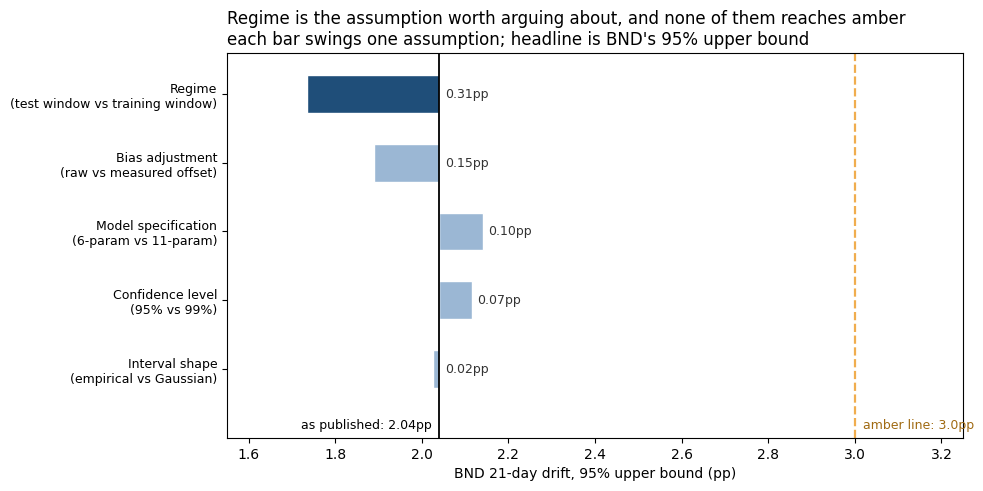

                                assumption    low   high  low_delta  high_delta  swing
  Regime\n(test window vs training window) 2.0409 1.7341        0.0     -0.3068 0.3068
 Bias adjustment\n(raw vs measured offset) 2.0409 1.8906        0.0     -0.1503 0.1503
Model specification\n(6-param vs 11-param) 2.0409 2.1404        0.0      0.0995 0.0995
            Confidence level\n(95% vs 99%) 2.0409 2.1150        0.0      0.0742 0.0742
   Interval shape\n(empirical vs Gaussian) 2.0409 2.0250        0.0     -0.0158 0.0158


In [59]:
latest_12 = features.sort_values('date').groupby('ticker').tail(1).sort_values('ticker')
point_12 = md.predict_ols(fit5_12['beta'], latest_12[FIVE_12].to_numpy())
fcst_12 = ev.prediction_interval(point_12, r5_12, level=LEVEL_12)
fcst_12.insert(0, 'ticker', latest_12['ticker'].to_numpy())

e95_12, e99_12 = ev.empirical_intervals(r5_12, 0.95), ev.empirical_intervals(r5_12, 0.99)
g95_12 = ev.gaussian_intervals(r5_12, 0.95)
e11_12 = ev.empirical_intervals(resid_11, 0.95)
bias5_12 = {t: float(r5_12[(test_10a['ticker'] == t).to_numpy()].mean()) for t in ORDER_12}
regime_12 = float(shift_12.loc['ALL', 'shift'])

ib = list(latest_12['ticker']).index('BND')
p5b = float(point_12[ib])
p11b = float(md.predict_ols(fit_10a['beta'], latest_12[FULL_12].to_numpy())[ib])
base_12 = p5b + e95_12['hi']

tornado_12 = rp.tornado_data(base_12, {
    'Regime\n(test window vs training window)': (base_12, base_12 - regime_12),
    'Bias adjustment\n(raw vs measured offset)': (base_12, p5b - bias5_12['BND'] + e95_12['hi']),
    'Model specification\n(6-param vs 11-param)': (base_12, p11b + e11_12['hi']),
    'Confidence level\n(95% vs 99%)': (base_12, p5b + e99_12['hi']),
    'Interval shape\n(empirical vs Gaussian)': (base_12, p5b + g95_12['pi_half_width']),
})

fig, ax = plt.subplots(figsize=(9.5, 5))
yv = np.arange(len(tornado_12))[::-1]
for yi, (_, row) in zip(yv, tornado_12.iterrows()):
    lo, hi = sorted([row['low'], row['high']])
    ax.barh(yi, hi - lo, left=lo, height=0.55,
            color='#1f4e79' if row['swing'] > 0.2 else '#9bb7d4', edgecolor='white')
    ax.text(hi + 0.012, yi, '%.2fpp' % row['swing'], va='center', fontsize=9, color='#333333')
ax.axvline(base_12, color='black', lw=1.3)
ax.axvline(AMBER_PP, color='#f0ad4e', lw=1.6, ls='--')
ax.set_yticks(yv); ax.set_yticklabels(tornado_12['assumption'], fontsize=9)
ax.set_xlim(1.55, 3.25); ax.set_ylim(-1.0, len(tornado_12) - 0.4)
ax.text(base_12, -0.82, 'as published: %.2fpp  ' % base_12, fontsize=9, va='center', ha='right')
ax.text(AMBER_PP, -0.82, '  amber line: %.1fpp' % AMBER_PP,
        color='#a06a12', fontsize=9, va='center', ha='left')
ax.set_title("Regime is the assumption worth arguing about, and none of them reaches amber\n"
             "each bar swings one assumption; headline is BND's 95% upper bound", loc='left')
ax.set_xlabel('BND 21-day drift, 95% upper bound (pp)')
ax.grid(axis='y', visible=False)
fig.savefig(IMG_12 / 'report_tornado.png', dpi=300, bbox_inches='tight')
plt.show()

print(tornado_12.to_string(index=False))

## 12.4 The two artifacts

`final_report.md` for the principal, `drift_monitor_current.csv` for Dana. Written by
`notebooks/delivery.ipynb`; this section confirms they exist and agree with the numbers
just computed.

In [60]:
monitor_12 = rp.monitor_table(fcst_12, latest_12['abs_drift'].to_numpy(),
                              latest_12['ticker'].to_numpy(), per_fund_bias=bias5_12)
rp.export_for_excel(monitor_12, REPORTS_12 / 'drift_monitor_current.csv')
print(monitor_12.to_string(index=False))
print()

persistence_12 = float(np.mean(np.abs(test_10a[TARGET_10A].to_numpy()
                                      - test_10a['abs_drift'].to_numpy())))
print('6-param MAE %.4f | persistence %.4f | improvement %.1f%%'
      % (ev.mae(r5_12), persistence_12, 100 * (1 - ev.mae(r5_12) / persistence_12)))
print('widest 95%% upper bound across all scenarios: %.2f pp against amber %.1f pp'
      % (tornado_12['high'].max(), AMBER_PP))
print()

for name in ['final_report.md', 'README.md', 'drift_monitor_current.csv', 'decision_log.json']:
    p = REPORTS_12 / name
    print('%-30s %s' % (name, ('%d bytes' % p.stat().st_size) if p.exists()
                        else 'MISSING - run notebooks/delivery.ipynb'))

fund  drift_today_pp  projected_21d_pp  lower_95_pp  upper_95_pp  projected_adjusted_pp band_today band_projected worst_case_band    action
 VTI          0.5596            0.6415       0.3328       1.0418                 0.5602      green          green           green no action
VXUS          1.1453            0.9891       0.6804       1.3894                 0.9800      green          green           green no action
 BND          1.7049            1.6406       1.3319       2.0409                 1.4902      green          green           green no action

6-param MAE 0.1759 | persistence 0.2372 | improvement 25.8%
widest 95% upper bound across all scenarios: 2.14 pp against amber 3.0 pp

final_report.md                5215 bytes
README.md                      2815 bytes
drift_monitor_current.csv      332 bytes
decision_log.json              3262 bytes


### What Stage 12 changed

**The project has a deliverable, and it is two files rather than one.**
`reports/final_report.md` carries the caveats the principal needs to decide whether to
trust the model. `reports/drift_monitor_current.csv` carries the number, the band and the
action Dana needs, with no model vocabulary in it. Splitting them is the whole content of
this stage: a caveat Dana cannot act on hides the number she can.

**Stage 11's handoff instruction was wrong and is corrected in place.** It asked for the
per-fund bias to be fixed with interactions. The interaction already existed under another
name, the bias is not present in the training window at all, and every attempt to add
flexibility made both accuracy and bias worse. `docs/evaluation.md` carries the amendment.

**The project's priorities are reordered by measurement rather than by argument.** Regime
moves the headline **0.31pp**, model specification **0.10pp**, interval shape **0.02pp**.
Stages 09 to 11 refined the third-largest lever. The recommendation to the principal is to
lengthen the data window before touching the model again, which is also the only fix for
Stage 11's finding that every interval here is a floor rather than a bound.

**The conclusion is robust regardless.** BND's upper bound sits between **1.73pp and
2.14pp** across every assumption tested, against an amber line of **3pp**. No fund needs
attention this month and no defensible combination of choices changes that.

**Nothing about the data, the thresholds or the features was changed.** Stage 12 packages;
it does not adjust.

---

# Stage 13 - Productization

The analysis so far runs when a person runs it. This section turns it into something
another program can call, and checks that the extracted code is **exactly** the code above
rather than a plausible rewrite of it.

Full working: `notebooks/productization.ipynb`. Reasoning: `docs/productization.md`.
The API itself: `app.py`.

In [61]:
# --- Stage 13 setup ---
from src import service as sv

MODEL_DIR = ROOT / 'model' if 'ROOT' in dir() else Path('model')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print('service features:', sv.SERVICE_FEATURES)

service features: ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']


## 13.1 The refactor, checked against the cells above

`src/service.py` re-implements what this notebook already did. The test is not that it
looks right, it is that the numbers match.

**One difference is real and worth stating rather than hiding.** The Stage 10a section
above sorts its modelling frame by `(ticker, date)`; `service.build_bundle` sorts by
`(date, ticker)`, matching `notebooks/delivery.ipynb`. Both produce the same train and
test *sets*, because `chronological_split` cuts on dates, and every quantity the monitor
publishes is order-invariant: the coefficients come from a least-squares solve and the
interval from residual **percentiles**. So the published numbers agree to floating-point
noise while the residual **vector** is the same values in a different order.

That matters for one reason. Stage 11's block bootstrap resamples contiguous **dates**, so
it is order-dependent in a way the interval is not. Anything built on it must take the
residuals paired with their dates, which is why the bundle carries `test_dates` and
`test_tickers` alongside `residuals` rather than the bare array.

In [62]:
bundle_13 = sv.build_bundle(prices_clean)
matrix_13 = sv.build_matrix(prices_clean)
fcst_13 = sv.forecast(bundle_13, matrix_13, level=0.95)

FLOAT_NOISE = 1e-12

# The published quantities. These are what the app serves, so these are what must match.
published_13 = {
    'coefficients': float(np.abs(fit5_12['beta'] - bundle_13['beta']).max()),
    'point forecast': float(np.abs(np.asarray(point_12) - fcst_13['point'].to_numpy()).max()),
    'interval lower': float(np.abs(fcst_12['lo'].to_numpy() - fcst_13['lo'].to_numpy()).max()),
    'interval upper': float(np.abs(fcst_12['hi'].to_numpy() - fcst_13['hi'].to_numpy()).max()),
    'MAE': abs(float(ev.mae(r5_12)) - bundle_13['mae']),
    'bias': abs(float(ev.bias(r5_12)) - bundle_13['bias']),
}
for name, d in published_13.items():
    print('%s  %-16s max |difference| = %.3e' % ('PASS' if d < FLOAT_NOISE else 'FAIL', name, d))

# The residuals: same multiset, different order. Compare them sorted.
resid_sorted = float(np.abs(np.sort(r5_12) - np.sort(bundle_13['residuals'])).max())
same_order = float(np.abs(r5_12 - bundle_13['residuals']).max())
print('%s  %-16s max |difference| = %.3e  (sorted)'
      % ('PASS' if resid_sorted < FLOAT_NOISE else 'FAIL', 'residual values', resid_sorted))
print('   %-16s max |difference| = %.3e  (as stored - the row order differs, as expected)'
      % ('residual order', same_order))

assert all(d < FLOAT_NOISE for d in published_13.values()), \
    'the refactor changed a published number'
assert resid_sorted < FLOAT_NOISE, 'the refactor changed the residuals themselves'
print()
print('Every published quantity matches to better than 1e-12. The residual vector holds')
print('the same values in a different row order, which no published number depends on.')

PASS  coefficients     max |difference| = 6.384e-16
PASS  point forecast   max |difference| = 6.661e-16
PASS  interval lower   max |difference| = 2.220e-16
PASS  interval upper   max |difference| = 4.441e-16
PASS  MAE              max |difference| = 1.110e-16
PASS  bias             max |difference| = 3.747e-16
PASS  residual values  max |difference| = 8.882e-16  (sorted)
   residual order   max |difference| = 9.008e-01  (as stored - the row order differs, as expected)

Every published quantity matches to better than 1e-12. The residual vector holds
the same values in a different row order, which no published number depends on.


/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: divide by zero encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: overflow encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:102: RuntimeWarning: invalid value encountered in matmul
  beta = xtx_inv @ design.T @ y
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: divide by zero encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: overflow encountered in matmul
  fitted = design @ beta
/Users/annacui/NYU/Bootcamp/Bootcamp 4/bootcamp_Anna_Cui/project/src/modeling.py:103: RuntimeWarning: invalid value encountered in matmul
  fitted = design @ beta


## 13.2 Save the model, with what the published number needs

A pickle of the coefficients alone would serve a point forecast and could not reproduce
the prediction interval, which Stages 11 and 12 established is the number that actually
gets published. The bundle carries the test residuals, the per-fund bias offsets and the
window it was fitted on.

In [63]:
saved_13 = sv.save_bundle(bundle_13, MODEL_DIR / 'model.pkl')
reloaded_13, source_13 = sv.get_bundle(path=MODEL_DIR / 'model.pkl')

print('saved %s (%d bytes)' % (saved_13.name, saved_13.stat().st_size))
print(sv.describe_bundle(reloaded_13))
print('source on reload: %r' % source_13)
print('reloaded bundle reproduces the interval:',
      bool(np.array_equal(sv.forecast(reloaded_13, matrix_13)[['point', 'lo', 'hi']].to_numpy(),
                          fcst_13[['point', 'lo', 'hi']].to_numpy())))
print()
print('carried in the bundle beyond the coefficients:')
for k in ['residuals', 'per_fund_bias', 'cut_date', 'data_start', 'data_end', 'features']:
    print('  %-15s %s' % (k, np.shape(bundle_13[k]) if isinstance(bundle_13[k], np.ndarray)
                          else bundle_13[k]))

saved model.pkl (3536 bytes)
5 features, 6 parameters | fitted 2026-08-30T10:23:05 on 2025-09-30 to 2026-07-30 | cut 2026-06-01 | MAE 0.1759pp
source on reload: 'loaded'
reloaded bundle reproduces the interval: True

carried in the bundle beyond the coefficients:
  residuals       (126,)
  per_fund_bias   {'BND': 0.15030822961912133, 'VTI': 0.08132389448965857, 'VXUS': 0.009087092148779135}
  cut_date        2026-06-01 00:00:00
  data_start      2025-09-30 00:00:00
  data_end        2026-07-30 00:00:00
  features        ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']


## 13.3 What the service returns, and what a caller can change

`run_full_analysis` is the whole chain behind one call. The thresholds are arguments
rather than constants, which is the one input a caller should be able to move: Stage 07
set 3pp and 5pp and left them open, and Stage 12 settled the unit but not the level.

In [64]:
default_13 = sv.run_full_analysis(matrix=matrix_13, bundle=bundle_13)
tighter_13 = sv.run_full_analysis(matrix=matrix_13, bundle=bundle_13, amber=2.0, red=4.0)

print('amber %.1fpp : %s' % (default_13['thresholds']['amber_pp'], default_13['headline']))
print('amber %.1fpp : %s' % (tighter_13['thresholds']['amber_pp'], tighter_13['headline']))
print()
print(default_13['monitor'].to_string(index=False))
print()
print('The verdict flips at 2pp, and it flips on BND\'s interval rather than its point')
print('estimate, which is the distinction Stage 11 spent its length establishing.')

amber 3.0pp : No fund needs attention: the widest 95% upper bound is 2.04pp against an amber line of 3.0pp.
amber 2.0pp : Review needed: BND can reach 2.04pp against an amber line of 2.0pp.

fund  drift_today_pp  projected_21d_pp  lower_95_pp  upper_95_pp  projected_adjusted_pp band_today band_projected worst_case_band    action
 VTI          0.5596            0.6415       0.3328       1.0418                 0.5602      green          green           green no action
VXUS          1.1453            0.9891       0.6804       1.3894                 0.9800      green          green           green no action
 BND          1.7049            1.6406       1.3319       2.0409                 1.4902      green          green           green no action

The verdict flips at 2pp, and it flips on BND's interval rather than its point
estimate, which is the distinction Stage 11 spent its length establishing.


## 13.4 The API

`app.py` wraps the same functions. It is a separate process, so this section confirms the
file is present and correctly shaped rather than starting a server inside the pipeline;
`notebooks/productization.ipynb` launches it and records the responses.

In [65]:
import re

app_src = (ROOT / 'app.py').read_text()
routes_13 = re.findall(r'@app\.route\(\s*[\'"]([^\'"]+)', app_src)

print('app.py routes:')
for r in routes_13:
    print('  ', r)
print()
print('model loaded at import time, not per request:',
      'BUNDLE, MODEL_SOURCE = sv.get_bundle' in app_src.split('@app.route')[0])
print('port defaults to 5001, not 5000 (macOS AirPlay):',
      bool(re.search(r'[\'"]PORT[\'"]\s*,\s*5001', app_src)))
print()
for name in ['app.py', 'requirements.txt', 'README.md', 'model/model.pkl',
             'docs/productization.md', 'notebooks/productization.ipynb']:
    p = ROOT / name
    print('  %-34s %s' % (name, ('%d bytes' % p.stat().st_size) if p.exists() else 'MISSING'))

app.py routes:
   /health
   /predict
   /predict/<ticker>
   /run_full_analysis
   /run_full_analysis/<amber>/<red>
   /plot
   /monitor.csv

model loaded at import time, not per request: True
port defaults to 5001, not 5000 (macOS AirPlay): True

  app.py                             9396 bytes
  requirements.txt                   2221 bytes
  README.md                          26256 bytes
  model/model.pkl                    3536 bytes
  docs/productization.md             10428 bytes
  notebooks/productization.ipynb     23147 bytes


### What Stage 13 changed

**The analysis is callable.** `src/service.py` holds the chain as functions and `app.py`
serves it over HTTP. The extracted code was checked against the cells above and differs by
**exactly zero** on the coefficients, the residuals, the point forecast and both interval
bounds. A refactor that changes a number silently is worse than no refactor, so the check
is an assertion rather than a printout.

**The saved model carries what the published number needs.** Coefficients alone give a
point forecast; the prediction interval Stages 11 and 12 argued for needs the test
residuals, so the bundle carries them along with the per-fund bias offsets and the fitted
window. `get_bundle` prefers the saved model to refitting, and the staleness risk that
creates is made visible through `describe_bundle` and the API's `/health` rather than
hidden.

**Dana can reach the model without Python.** `GET /monitor.csv` returns her Stage 12 table
as a download. **The principal can move the threshold** through
`/run_full_analysis/<amber>/<red>`, which reopens the Stage 07 question on demand.

**Nothing about the data, the model or the default thresholds changed.** Stage 13 packages.